# Wild-Tool-Bench — Strategy Analysis (120B vs. Laguna)

Analysis of the tool-selection-strategy runs for two executing models — `openai/gpt-oss-120b` ("120B")
and "Laguna" — across:

`in_context`, `embedding`, `embedding_context`, `reranker`, `reranker_context`, `hierarchical`

Data sources used (per model):
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_metric.json` / `score/laguna_<strategy>/langgraph/Wild-Tool-Bench_metric.json` — official aggregated accuracy/optimality/progress metrics.
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_score.jsonl` / `score/laguna_<strategy>/langgraph/Wild-Tool-Bench_score.jsonl` — per-task correctness (`label`), optimality, predicted tool calls and final answers.
- `result_v3_120B/<strategy>/langgraph/Wild-Tool-Bench_metrics_summary.jsonl` / `result_laguna/<strategy>/langgraph/Wild-Tool-Bench_metrics_summary.jsonl` — per-task token counts and latency.
- `result_v3_120B/<strategy>/tool_selection_logs.jsonl` / `result_laguna/<strategy>/tool_selection_logs.jsonl` — candidate tools handed to the LLM by the selection strategy (absent for `in_context`).
- `result_v3_120B/<strategy>/tool_call_logs.jsonl` / `result_laguna/<strategy>/tool_call_logs.jsonl` — tool calls actually issued by the executing LLM.
- `data/Wild-Tool-Bench.jsonl` — benchmark definition incl. gold trajectories (`english_answer_list`), task types and turn subtypes (shared across models).

Sections:
1. Setup & data loading
2. Official WTB metrics (task/session accuracy, task type, layer, turn subtype, optimality, progress)
3. Token count & latency comparison
4. Token count vs. accuracy
5. Inter-strategy comparison: unique wins
6. Gold-tool coverage of the tool selection stage
7. Rank position of the executing LLM's tool calls
8. Single-task deep dive: gold trajectory vs. selected/executed tools & answer
9. Model comparison: 120B vs. Laguna

10. Improvement Strategies: ToolReAGT

11. Why ToolReAGT can retrieve better but still perform worse14. Statistical task-accuracy comparison

12. Request-level join: selection output vs executor behavior13. Why good early tool picks still fail: failure-type breakdown

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "wild-tool-bench":
    ROOT = ROOT / "wild-tool-bench"

STRATEGIES = ["in_context", "embedding", "embedding_context", "reranker", "reranker_context", "hierarchical"]
STRATEGY_LABELS = {
    "in_context": "In-Context",
    "embedding": "Embedding",
    "embedding_context": "Embedding+Context",
    "reranker": "Reranker",
    "reranker_context": "Reranker+Context",
    "hierarchical": "Hierarchical",
}
COLORS = dict(zip(STRATEGIES, plt.cm.tab10.colors))

MODELS = ["120B", "Laguna"]
MODEL_LABELS = {"120B": "GPT-OSS-120B", "Laguna": "Laguna"}

# Per-model score directory names and result roots. `laguna_in__context` uses a
# double underscore in its score dir name, unlike every other laguna strategy.
SCORE_DIRS = {
    "120B": {s: f"120B_{s}" for s in STRATEGIES},
    "Laguna": {**{s: f"laguna_{s}" for s in STRATEGIES}, "in_context": "laguna_in__context"},
}
RESULT_ROOTS = {"120B": "result_v3_120B", "Laguna": "result_laguna"}

DATA_FILE = ROOT / "data/Wild-Tool-Bench.jsonl"
SCORE_ROOT = ROOT / "score"


def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Setup & data loading

Builds a gold-task index (task type, turn subtype, layer, gold tool trajectory) from the benchmark
definition, then loads the per-task score/metrics/selection/tool-call logs for every strategy.


In [2]:
benchmark = read_jsonl(DATA_FILE)


def build_gold_index(rows: list[dict]) -> dict[tuple[str, int], dict]:
    """One entry per (session id, task_idx) with gold task metadata and the gold tool trajectory."""
    idx = {}
    for rec in rows:
        eid = rec["id"]
        n = len(rec["english_tasks"])
        for i in range(n):
            gold_actions = rec["english_answer_list"][i] if i < len(rec["english_answer_list"]) else []
            gold_tools = [
                a.get("action", {}).get("name")
                for a in gold_actions
                if a.get("action", {}).get("name") and a["action"]["name"] != "prepare_to_answer"
            ]
            idx[(eid, i)] = {
                "task_type": rec["english_task_types"][i],
                "turn_type": "First Turn" if not rec["turn_types"][i] else "Subsequent Turn",
                "turn_subtype": rec["english_turn_subtypes"][i - 1] if i > 0 else None,
                "layer": i,
                "query": rec["english_tasks"][i],
                "gold_tools": gold_tools,
                "gold_tools_unique": sorted(set(gold_tools)),
                "gold_actions": gold_actions,
            }
    return idx


gold_index = build_gold_index(benchmark)
print(f"{len(gold_index)} gold tasks across {len(benchmark)} sessions")


1024 gold tasks across 256 sessions


In [3]:
def extract_step_info(inference_log: dict) -> tuple[list[str], str | None]:
    """Returns (predicted tool names in call order, final answer text) for one task's inference log."""
    step_keys = sorted(
        (k for k in inference_log if str(k).startswith("step_")),
        key=lambda x: int(x.split("_")[1]),
    )
    predicted_tools, final_answer = [], None
    for sk in step_keys:
        out = inference_log[sk].get("inference_output", {}) or {}
        for tc in out.get("tool_calls", []) or []:
            fn = tc.get("function", {}) or {}
            if fn.get("name"):
                predicted_tools.append(fn["name"])
        if out.get("content"):
            final_answer = out["content"]
    return predicted_tools, final_answer


def load_strategy_tasks(model: str, strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task correctness/optimality/predicted tools/final answer from score JSONL."""
    score_rows = read_jsonl(SCORE_ROOT / SCORE_DIRS[model][strategy] / "langgraph/Wild-Tool-Bench_score.jsonl")
    tasks = {}
    for rec in score_rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            log = item.get("inference_log", {}) or {}
            predicted_tools, final_answer = extract_step_info(log) if log else ([], None)
            tasks[(eid, i)] = {
                "correct": item.get("label") == "correct",
                "optimal": bool(item.get("is_optimal", False)),
                "predicted_tools": predicted_tools,
                "final_answer": final_answer,
                "name_correct": item.get("action_name_label") == "correct",
                "args_correct": item.get("action_arguments_label") == "correct",
            }
    return tasks


def load_strategy_token_metrics(model: str, strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task token/latency figures from metrics summary JSONL."""
    rows = read_jsonl(ROOT / RESULT_ROOTS[model] / strategy / "langgraph/Wild-Tool-Bench_metrics_summary.jsonl")
    out = {}
    for rec in rows:
        eid = rec["id"]
        for pt in rec["metrics"].get("per_task", []):
            out[(eid, pt["task_idx"])] = {
                "input_tokens": pt.get("input_tokens", 0) or 0,
                "output_tokens": pt.get("output_tokens", 0) or 0,
                "total_tokens": pt.get("total_tokens", 0) or 0,
                "llm_latency_s": pt.get("llm_latency_s", 0) or 0,
                "embedding_total_tokens": pt.get("embedding_total_tokens", 0) or 0,
                "reranker_total_tokens": pt.get("reranker_total_tokens", 0) or 0,
                "selector_total_tokens": pt.get("selector_total_tokens", 0) or 0,
            }
    return out


def _load_final_selection_rows(model: str, strategy: str) -> list[dict]:
    path = ROOT / RESULT_ROOTS[model] / strategy / "tool_selection_logs.jsonl"
    if not path.exists():
        return []
    rows = read_jsonl(path)
    rows.sort(key=lambda r: r.get("timestamp", 0))
    final_by_request = {}
    for row in rows:
        final_by_request[row.get("request_id")] = row
    return sorted(final_by_request.values(), key=lambda r: r.get("timestamp", 0))


def load_strategy_selection(model: str, strategy: str) -> dict[tuple[str, int], set[str]]:
    out = defaultdict(set)
    for row in _load_final_selection_rows(model, strategy):
        out[(row["test_entry_id"], row["task_idx"])].update(row.get("selected_tool_names", []))
    return out


def load_strategy_selection_ranked(model: str, strategy: str) -> dict[tuple[str, int], list[str]]:
    out = {}
    for row in _load_final_selection_rows(model, strategy):
        key = (row["test_entry_id"], row["task_idx"])
        if key not in out:
            out[key] = row.get("selected_tool_names", []) or []
    return out


def load_strategy_tool_calls(model: str, strategy: str) -> dict[tuple[str, int], list[dict]]:
    rows = read_jsonl(ROOT / RESULT_ROOTS[model] / strategy / "tool_call_logs.jsonl")
    rows.sort(key=lambda r: r.get("timestamp", 0))
    out = defaultdict(list)
    for row in rows:
        key = (row["test_entry_id"], row["task_idx"])
        for tc in row.get("returned_tool_calls", []) or []:
            out[key].append({"name": tc.get("name"), "arguments": tc.get("arguments")})
    return out


all_data = {}
for m in MODELS:
    all_data[m] = {}
    for s in STRATEGIES:
        all_data[m][s] = {
            "tasks": load_strategy_tasks(m, s),
            "tokens": load_strategy_token_metrics(m, s),
            "selection": load_strategy_selection(m, s),
            "selection_ranked": load_strategy_selection_ranked(m, s),
            "tool_calls": load_strategy_tool_calls(m, s),
            "metric": json.load(open(SCORE_ROOT / SCORE_DIRS[m][s] / "langgraph/Wild-Tool-Bench_metric.json")),
        }
        n_tasks = len(all_data[m][s]["tasks"])
        n_correct = sum(t["correct"] for t in all_data[m][s]["tasks"].values())
        print(f"{m:8s} {s:20s} tasks={n_tasks:4d}  correct={n_correct:4d}  acc={n_correct / n_tasks:.4f}")


120B     in_context           tasks=1024  correct= 371  acc=0.3623
120B     embedding            tasks=1024  correct= 327  acc=0.3193
120B     embedding_context    tasks=1024  correct= 367  acc=0.3584


120B     reranker             tasks=1024  correct= 314  acc=0.3066
120B     reranker_context     tasks=1024  correct= 360  acc=0.3516
120B     hierarchical         tasks=1024  correct= 373  acc=0.3643
Laguna   in_context           tasks=1024  correct= 411  acc=0.4014
Laguna   embedding            tasks=1024  correct= 353  acc=0.3447
Laguna   embedding_context    tasks=1024  correct= 394  acc=0.3848
Laguna   reranker             tasks=1024  correct= 360  acc=0.3516
Laguna   reranker_context     tasks=1024  correct= 401  acc=0.3916
Laguna   hierarchical         tasks=1024  correct= 420  acc=0.4102


In [4]:
rows = []
for m in MODELS:
    for s in STRATEGIES:
        tasks = all_data[m][s]["tasks"]
        tokens = all_data[m][s]["tokens"]
        for key, gold in gold_index.items():
            task = tasks.get(key, {"correct": False, "optimal": False, "predicted_tools": [], "final_answer": None})
            tok = tokens.get(key, {})
            rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "task_type": gold["task_type"],
                "turn_type": gold["turn_type"],
                "turn_subtype": gold["turn_subtype"],
                "layer": gold["layer"],
                "correct": task["correct"],
                "optimal": task["optimal"],
                "total_tokens": tok.get("total_tokens", 0),
                "input_tokens": tok.get("input_tokens", 0),
                "output_tokens": tok.get("output_tokens", 0),
                "llm_latency_s": tok.get("llm_latency_s", 0),
                "pipeline_tokens": tok.get("total_tokens", 0) + tok.get("embedding_total_tokens", 0)
                    + tok.get("reranker_total_tokens", 0) + tok.get("selector_total_tokens", 0),
            })
task_df = pd.DataFrame(rows)
task_df.head()


,model,strategy,task_id,task_idx,task_type,turn_type,turn_subtype,layer,correct,optimal,total_tokens,input_tokens,output_tokens,llm_latency_s,pipeline_tokens
0,120B,in_context,wild_tool_bench_0,0,Single-Tool,First Turn,NaN,0,True,True,116631,116330,301,14.888,116631
1,120B,in_context,wild_tool_bench_0,1,Single-Tool,Subsequent Turn,Partial Information,1,True,True,117053,116874,179,7.025,117053
2,120B,in_context,wild_tool_bench_0,2,Mixed Multi-Tool,Subsequent Turn,Partial Information,2,False,False,58818,58608,210,8.077,58818
3,120B,in_context,wild_tool_bench_0,3,Chat,Subsequent Turn,Coreferential Reference,3,True,True,59496,59251,245,9.354,59496
4,120B,in_context,wild_tool_bench_1,0,Single-Tool,First Turn,NaN,0,False,False,116400,116045,355,16.646,116400


## 2. Official WTB metrics

Directly visualizes the numbers already computed in each strategy's `Wild-Tool-Bench_metric.json`:
task/session accuracy, task-type accuracy, layer (turn position) accuracy, turn-subtype accuracy,
optimality score and progress info.


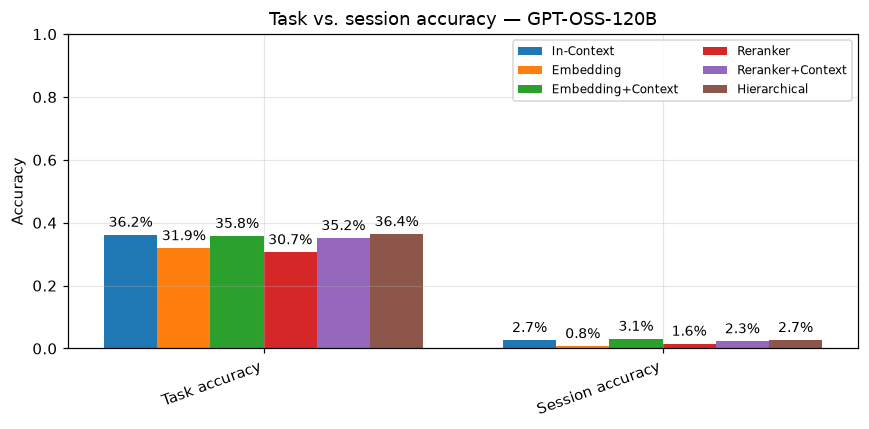

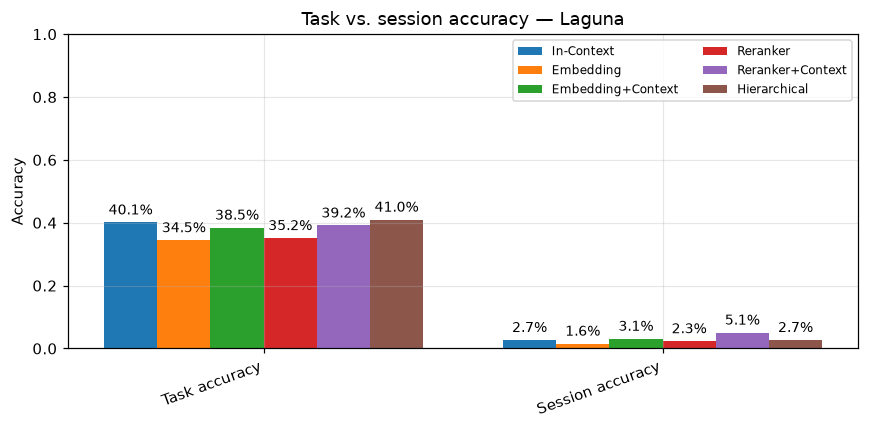

In [5]:
def grouped_bar(ax, categories: list[str], series: dict[str, list[float]], ylabel: str, title: str, pct: bool = True):
    n_groups, n_series = len(categories), len(series)
    width = 0.8 / n_series
    x = range(n_groups)

    for i, (s, values) in enumerate(series.items()):
        offsets = [xi + i * width - 0.4 + width / 2 for xi in x]

        bars = ax.bar(
            offsets,
            values,
            width=width,
            label=STRATEGY_LABELS[s],
            color=COLORS[s]
        )

        # Add value labels above each bar
        labels = [f"{v:.1%}" if pct else f"{v:.3f}" for v in values]
        ax.bar_label(
            bars,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if pct:
        ax.set_ylim(
            0,
            max(1.0, max(v for vals in series.values() for v in vals) * 1.15)
        )

    ax.legend(fontsize=8, ncol=2)


# Task & session accuracy, per model
for m in MODELS:
    categories = ["Task accuracy", "Session accuracy"]

    series = {
        s: [
            all_data[m][s]["metric"]["total_info"]["task"]["accuracy"],
            all_data[m][s]["metric"]["total_info"]["session"]["accuracy"]
        ]
        for s in STRATEGIES
    }

    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(
        ax,
        categories,
        series,
        "Accuracy",
        f"Task vs. session accuracy — {MODEL_LABELS[m]}"
    )

    plt.tight_layout()
    plt.show()


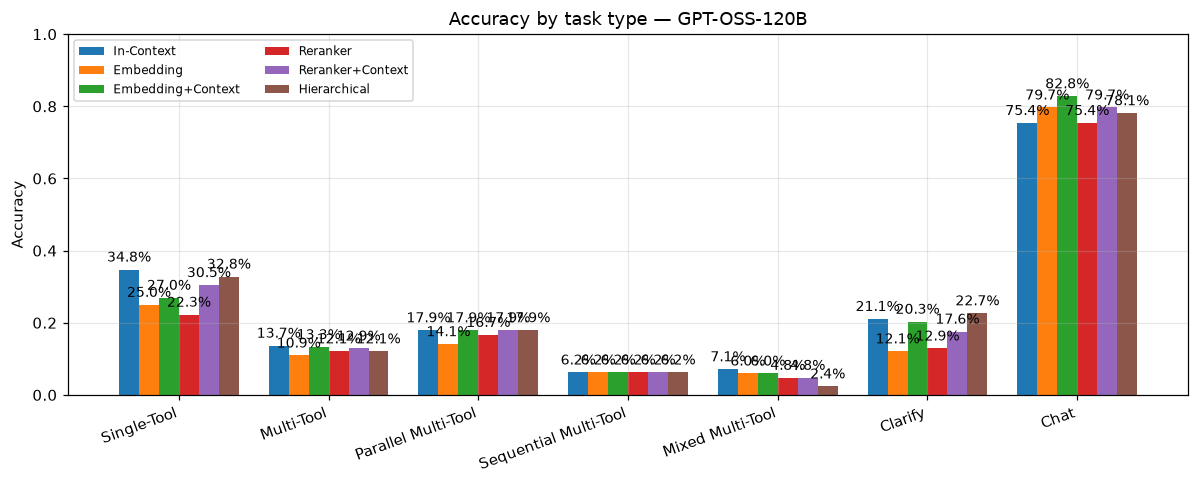

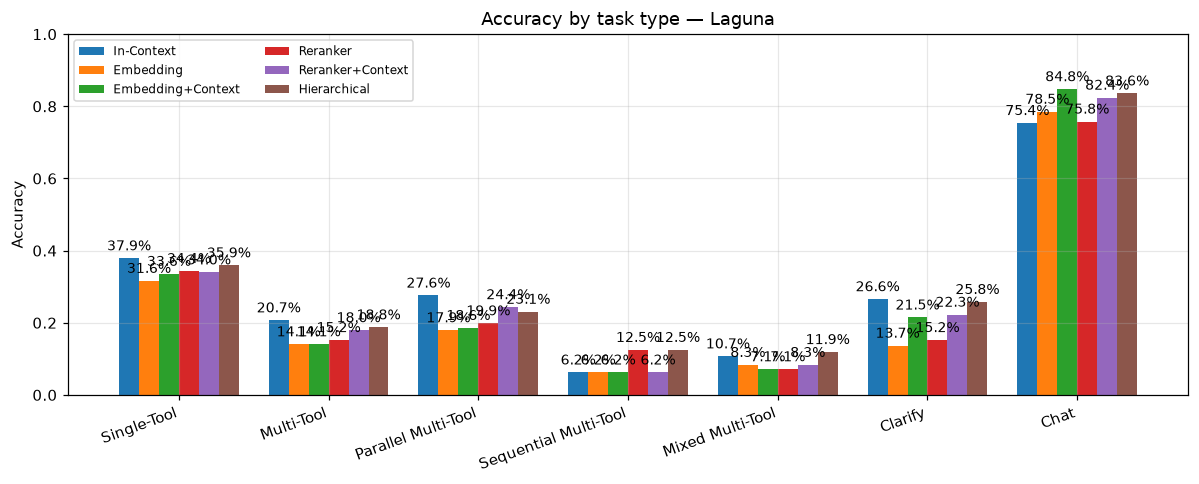

In [6]:
# Task-type accuracy, per model
task_types = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["task_type_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["task_type_info"][t]["accuracy"] for t in task_types] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(11, 4.5))
    grouped_bar(ax, task_types, series, "Accuracy", f"Accuracy by task type — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


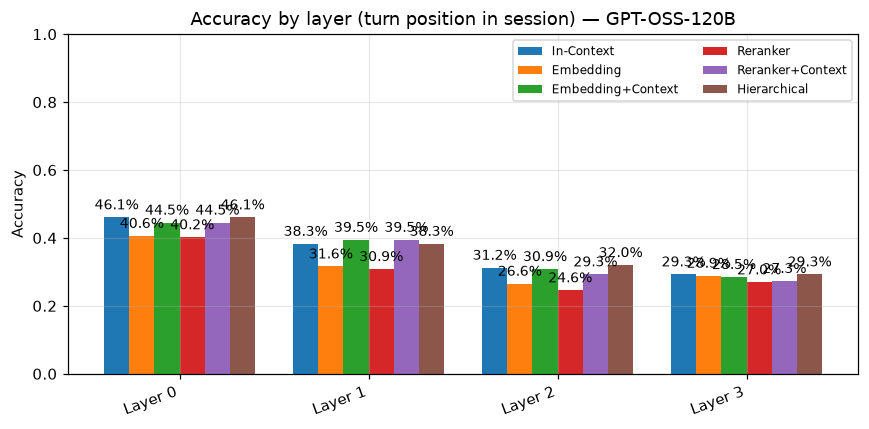

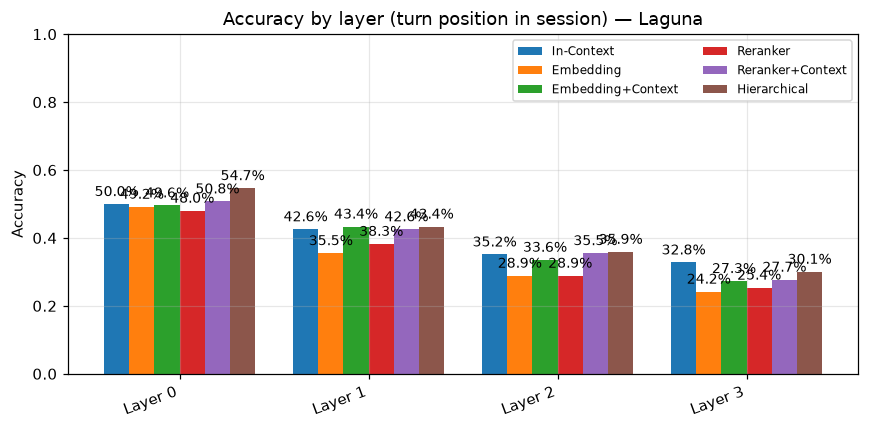

In [7]:
# Layer (turn position) accuracy, per model
layers = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["layer_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["layer_info"][l]["accuracy"] for l in layers] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, [f"Layer {l}" for l in layers], series, "Accuracy", f"Accuracy by layer (turn position in session) — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


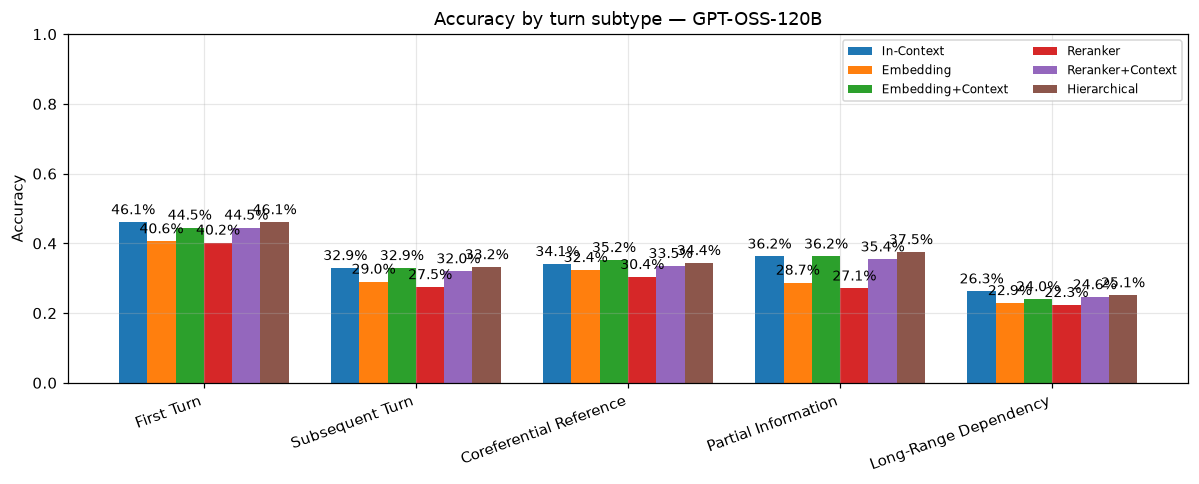

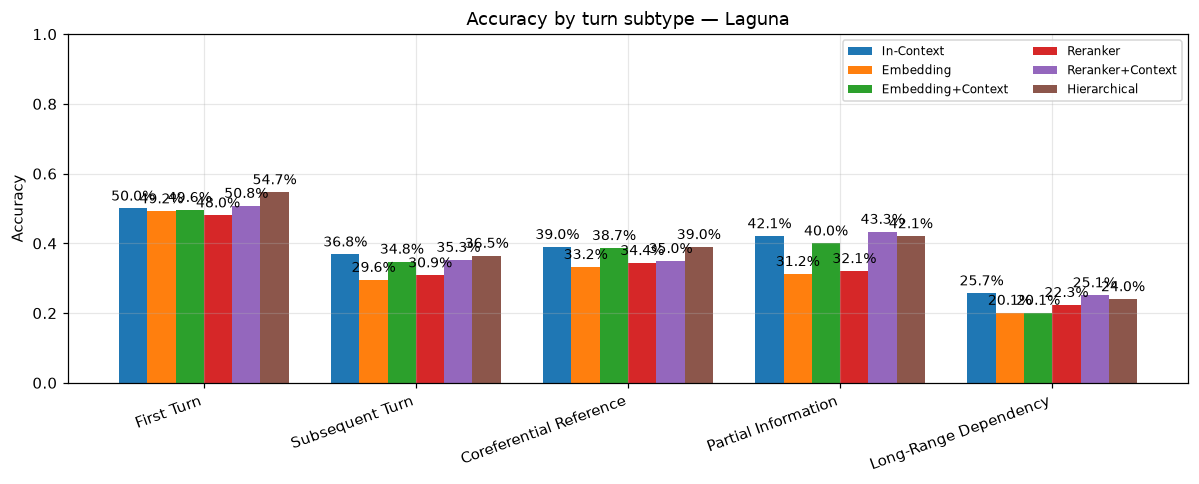

In [8]:
# Turn-subtype accuracy, per model
subtypes = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["turn_subtype_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["turn_subtype_info"][t]["accuracy"] for t in subtypes] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(11, 4.5))
    grouped_bar(ax, subtypes, series, "Accuracy", f"Accuracy by turn subtype — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


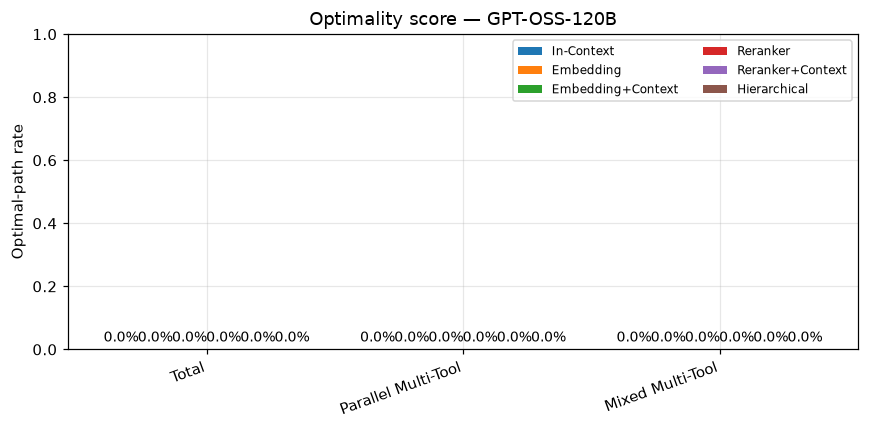

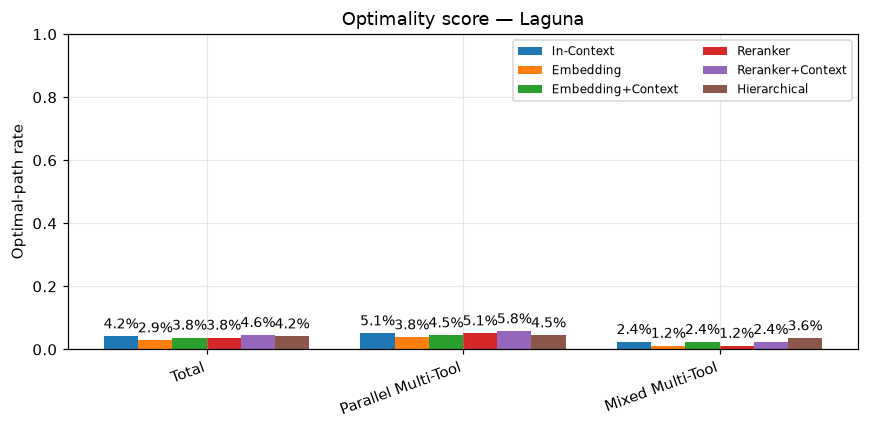

In [9]:
# Optimality score (only defined for Parallel/Mixed Multi-Tool, where multiple valid orderings exist), per model
optimal_keys = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["optimal_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["optimal_info"][k]["accuracy"] for k in optimal_keys] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, optimal_keys, series, "Optimal-path rate", f"Optimality score — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


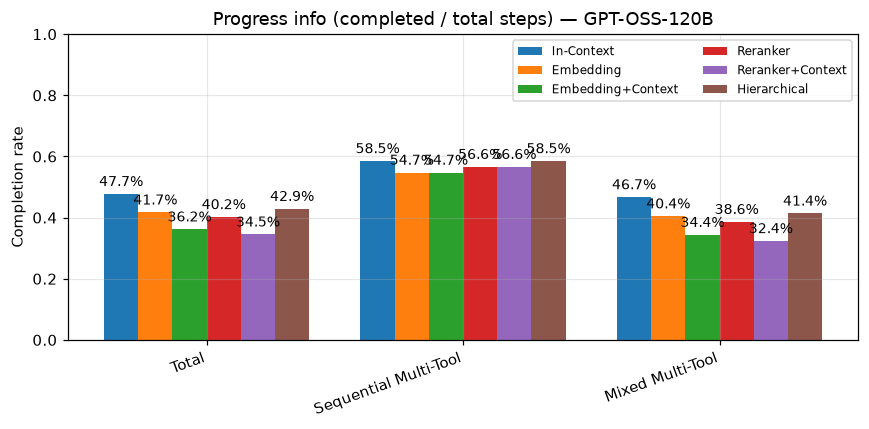

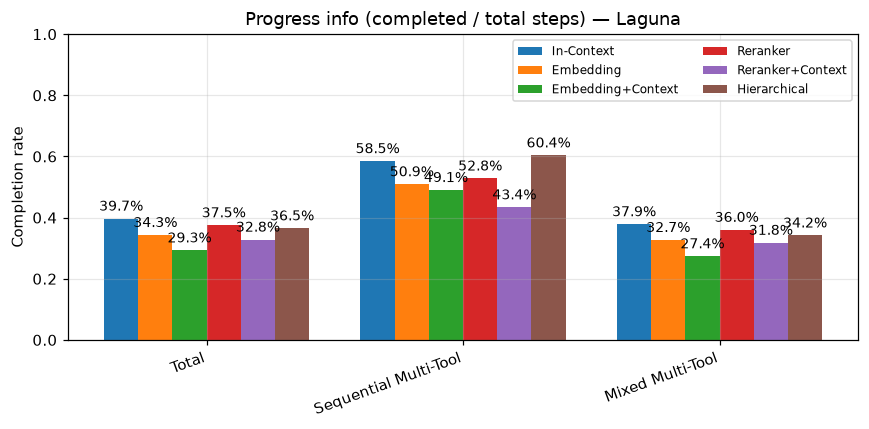

In [10]:
# Progress info: share of completed steps in multi-step tasks (Sequential/Mixed Multi-Tool), per model
progress_keys = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["progress_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["progress_info"][k]["rate"] for k in progress_keys] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, progress_keys, series, "Completion rate", f"Progress info (completed / total steps) — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


## 3. Token count & latency comparison

`total_tokens` / `llm_latency_s` are the executing LLM's own usage. `pipeline_tokens` additionally
includes the embedding/reranker/selector overhead spent on tool selection (0 for `in_context`, which
puts all tools directly in context).


In [11]:
token_summary = task_df.groupby(["model", "strategy"]).agg(
    total_llm_tokens=("total_tokens", "sum"),
    total_pipeline_tokens=("pipeline_tokens", "sum"),
    avg_llm_tokens=("total_tokens", "mean"),
    avg_input_tokens=("input_tokens", "mean"),
    avg_output_tokens=("output_tokens", "mean"),
    avg_pipeline_tokens=("pipeline_tokens", "mean"),
    total_latency_s=("llm_latency_s", "sum"),
    avg_latency_s=("llm_latency_s", "mean"),
).reindex(pd.MultiIndex.from_product([MODELS, STRATEGIES], names=["model", "strategy"]))
token_summary


total_llm_tokens  total_pipeline_tokens  \
model  strategy                                                     
120B   in_context                122702102              122702102   
       embedding                   3109992                3393091   
       embedding_context           3129975                4194331   
       reranker                    3154458                3550034   
       reranker_context            3168218                4252511   
       hierarchical                3386358               44625635   
Laguna in_context                248185134              248185134   
       embedding                   2862857                3140910   
       embedding_context           2808826                3803075   
       reranker                    2935722                3265764   
       reranker_context            2930489                3863921   
       hierarchical                3180148               41409882   

                          avg_llm_tokens  avg_input_tokens  avg_output_tokens  \
model  strategy                                                                 
120B   in_context          119826.271484     119140.279297         685.992188   
       embedding             3037.101562       2257.782227         779.319336   
       embedding_context     3056.616211       2282.949219         773.666992   
       reranker              3080.525391       2361.627930         718.897461   
       reranker_context      3093.962891       2339.713867         754.249023   
       hierarchical          3306.990234       2594.321289         712.668945   
Laguna in_context          242368.294922     241991.257812         377.037109   
       embedding             2795.758789       2559.987305         235.771484   
       embedding_context     2742.994141       2543.005859         199.988281   
       reranker              2866.916016       2658.735352         208.180664   
       reranker_context      2861.805664       2649.585938         212.219727   
       hierarchical          3105.613281       2881.081055         224.532227   

                          avg_pipeline_tokens  total_latency_s  avg_latency_s  
model  strategy                                                                
120B   in_context               119826.271484        28333.943      27.669866  
       embedding                  3313.565430        30766.191      30.045108  
       embedding_context          4096.026367        30845.640      30.122695  
       reranker                   3466.830078        29460.813      28.770325  
       reranker_context           4152.842773        31758.186      31.013854  
       hierarchical              43579.721680        36954.388      36.088270  
Laguna in_context               242368.294922         5276.455       5.152788  
       embedding                  3067.294922         2807.731       2.741925  
       embedding_context          3713.940430         3107.317       3.034489  
       reranker                   3189.222656         5284.329       5.160478  
       reranker_context           3773.360352         5236.192       5.113469  
       hierarchical              40439.337891        11363.455      11.097124

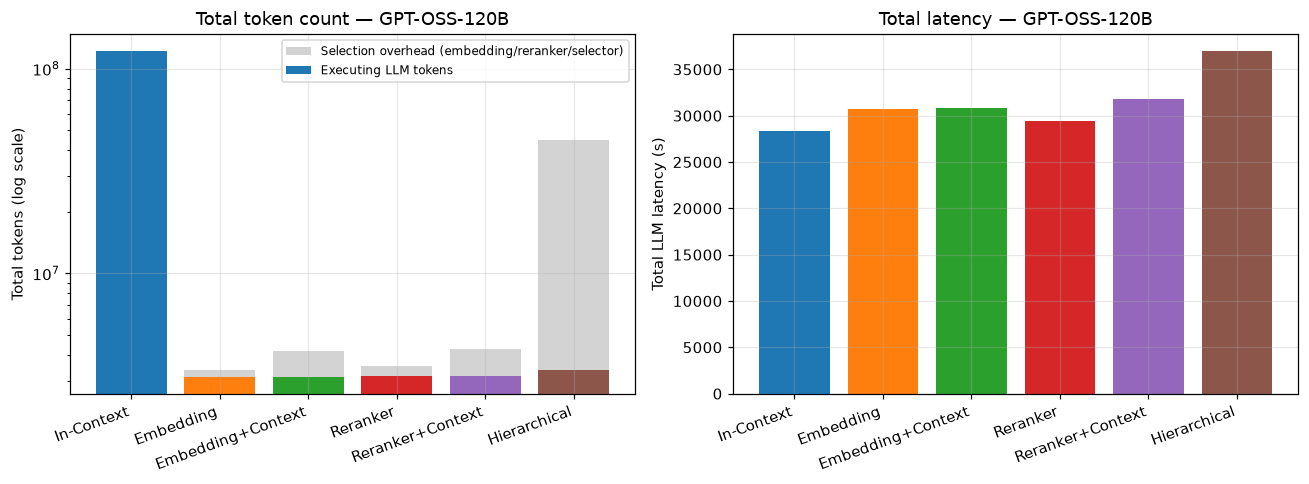

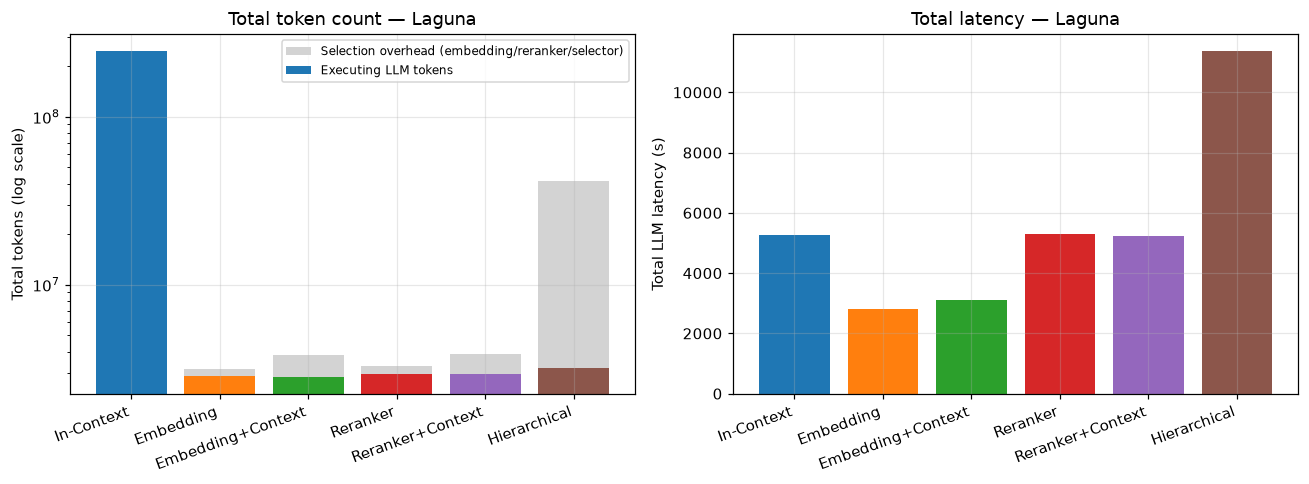

In [12]:
labels = [STRATEGY_LABELS[s] for s in STRATEGIES]
x = range(len(STRATEGIES))

for m in MODELS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    llm_totals = [token_summary.loc[(m, s), "total_llm_tokens"] for s in STRATEGIES]
    pipeline_totals = [token_summary.loc[(m, s), "total_pipeline_tokens"] for s in STRATEGIES]
    axes[0].bar(x, pipeline_totals, color="lightgray", label="Selection overhead (embedding/reranker/selector)")
    axes[0].bar(x, llm_totals, color=[COLORS[s] for s in STRATEGIES], label="Executing LLM tokens")
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=20, ha="right")
    axes[0].set_ylabel("Total tokens (log scale)")
    axes[0].set_yscale("log")
    axes[0].set_title(f"Total token count — {MODEL_LABELS[m]}")
    axes[0].legend(fontsize=8)

    lat_totals = [token_summary.loc[(m, s), "total_latency_s"] for s in STRATEGIES]
    axes[1].bar(x, lat_totals, color=[COLORS[s] for s in STRATEGIES])
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=20, ha="right")
    axes[1].set_ylabel("Total LLM latency (s)")
    axes[1].set_title(f"Total latency — {MODEL_LABELS[m]}")

    plt.tight_layout()
    plt.show()


## 4. Token count vs. accuracy

Average tokens spent per task against the task accuracy achieved, per strategy.


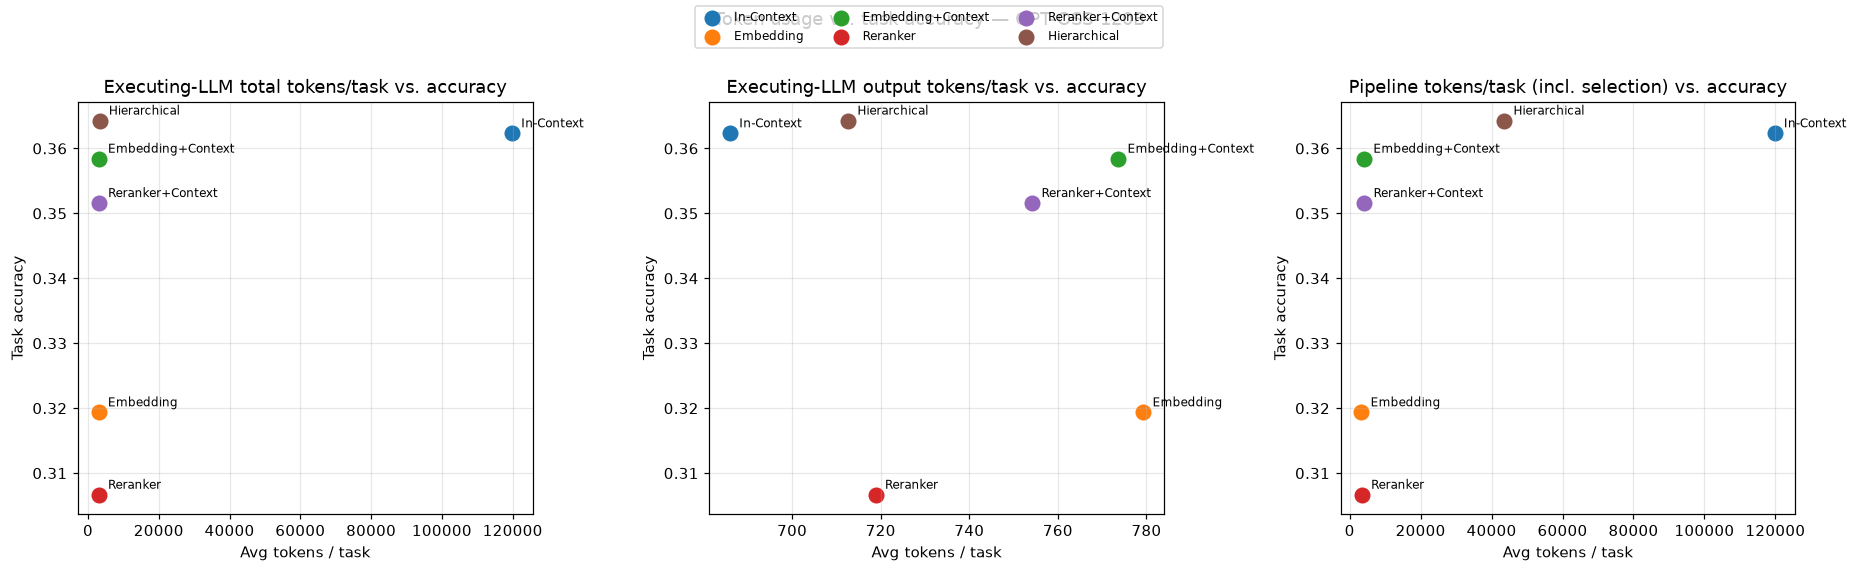

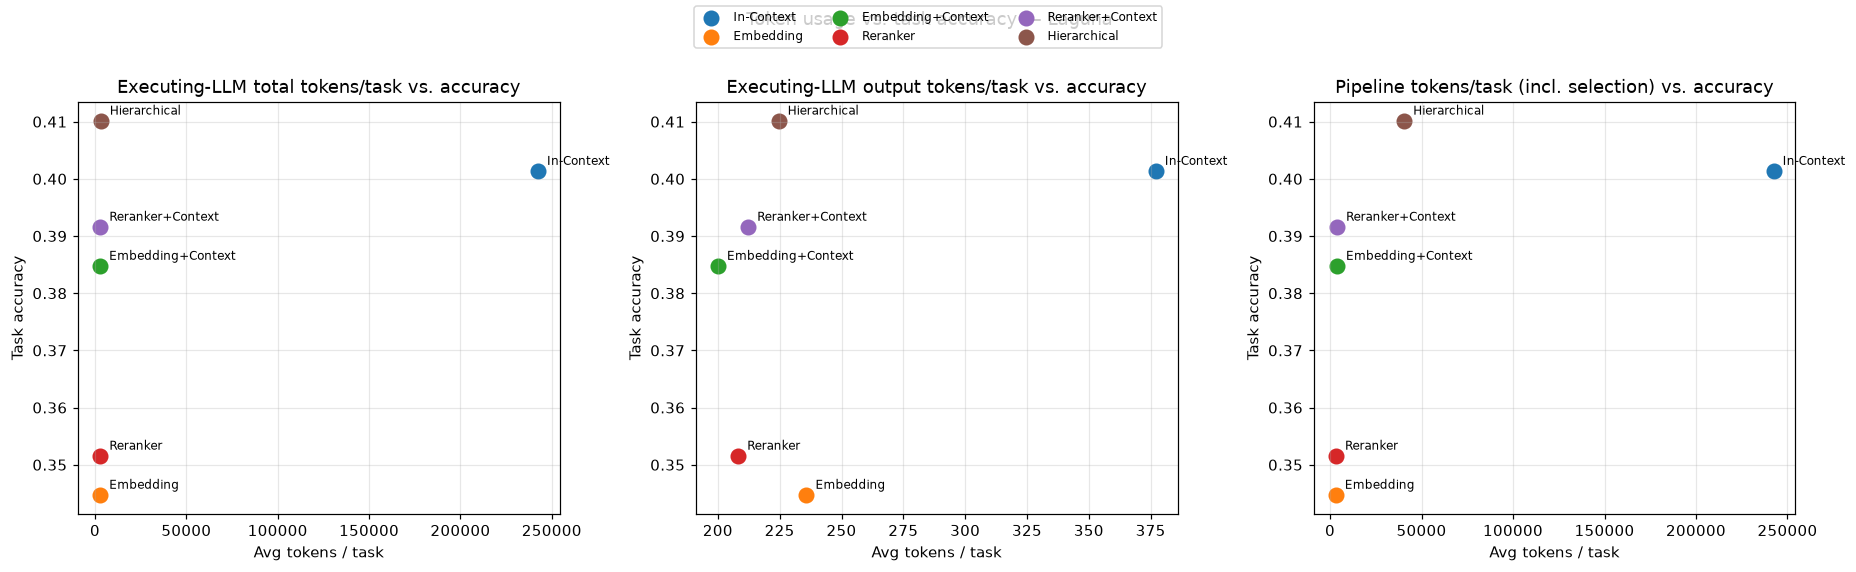

In [13]:
plot_specs = [
    ("avg_llm_tokens", "Executing-LLM total tokens/task vs. accuracy"),
    ("avg_output_tokens", "Executing-LLM output tokens/task vs. accuracy"),
    ("avg_pipeline_tokens", "Pipeline tokens/task (incl. selection) vs. accuracy"),
]

for m in MODELS:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, (token_col, title) in zip(axes, plot_specs):
        for s in STRATEGIES:
            acc = all_data[m][s]["metric"]["total_info"]["task"]["accuracy"]
            tok = token_summary.loc[(m, s), token_col]
            ax.scatter(tok, acc, s=90, color=COLORS[s], label=STRATEGY_LABELS[s])
            ax.annotate(
                STRATEGY_LABELS[s],
                (tok, acc),
                textcoords="offset points",
                xytext=(6, 4),
                fontsize=8,
            )
        ax.set_xlabel("Avg tokens / task")
        ax.set_ylabel("Task accuracy")
        ax.set_title(title)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8)
    fig.suptitle(f"Token usage vs. task accuracy — {MODEL_LABELS[m]}", y=1.03)
    plt.tight_layout()
    plt.show()


## 5. Inter-strategy comparison: unique wins

For each strategy, the number of tasks that *only that strategy* solved correctly (all other five
strategies got it wrong).


--- GPT-OSS-120B ---
In-Context           unique wins:  16   total correct: 371
Embedding            unique wins:   5   total correct: 327
Embedding+Context    unique wins:  11   total correct: 367
Reranker             unique wins:   3   total correct: 314
Reranker+Context     unique wins:   5   total correct: 360
Hierarchical         unique wins:  12   total correct: 373


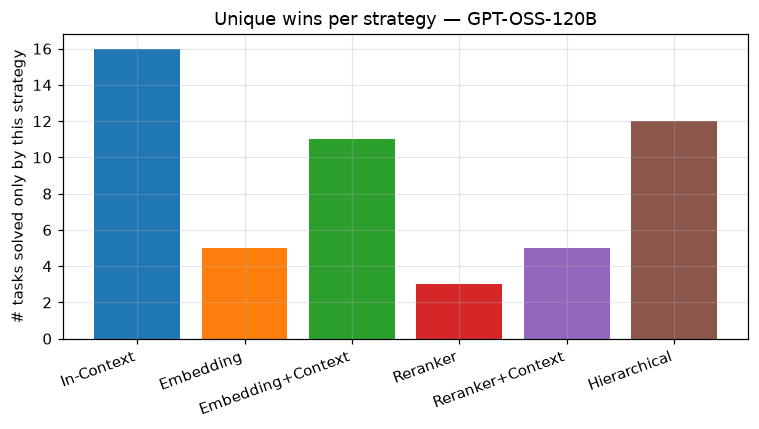

--- Laguna ---
In-Context           unique wins:  23   total correct: 411
Embedding            unique wins:   1   total correct: 353
Embedding+Context    unique wins:   7   total correct: 394
Reranker             unique wins:   2   total correct: 360
Reranker+Context     unique wins:   4   total correct: 401
Hierarchical         unique wins:   7   total correct: 420


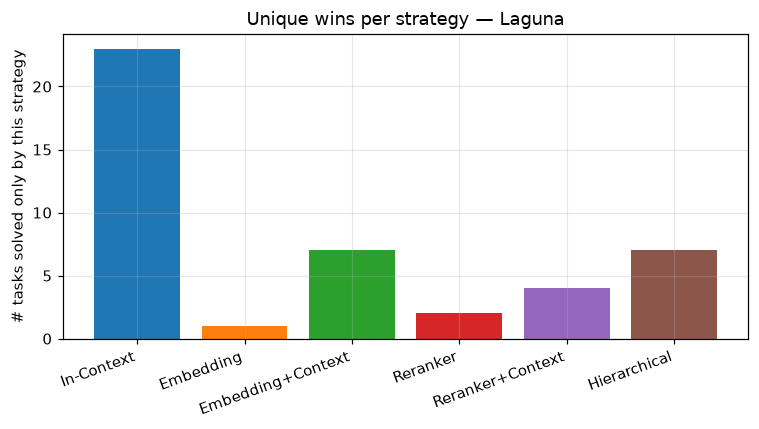

In [14]:
all_keys = set(gold_index.keys())
unique_wins_by_model = {}

for m in MODELS:
    correct_sets = {
        s: {key for key, t in all_data[m][s]["tasks"].items() if t["correct"]}
        for s in STRATEGIES
    }

    solved_by_count = Counter()
    for key in all_keys:
        for s in STRATEGIES:
            if key in correct_sets[s]:
                solved_by_count[key] += 1

    unique_wins = {}
    for s in STRATEGIES:
        unique_wins[s] = sorted(
            key for key in correct_sets[s]
            if solved_by_count[key] == 1
        )
    unique_wins_by_model[m] = unique_wins

    print(f"--- {MODEL_LABELS[m]} ---")
    for s in STRATEGIES:
        print(f"{STRATEGY_LABELS[s]:20s} unique wins: {len(unique_wins[s]):3d}   total correct: {len(correct_sets[s]):3d}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(len(STRATEGIES)), [len(unique_wins[s]) for s in STRATEGIES], color=[COLORS[s] for s in STRATEGIES])
    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], rotation=20, ha="right")
    ax.set_ylabel("# tasks solved only by this strategy")
    ax.set_title(f"Unique wins per strategy — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


## 6. Gold-tool coverage of the tool selection stage

For each task, the share of gold (ground-truth) tool names that appear anywhere in the set of tools
the selection stage handed to the LLM. `in_context` is excluded since it passes every tool through
without a selection step.


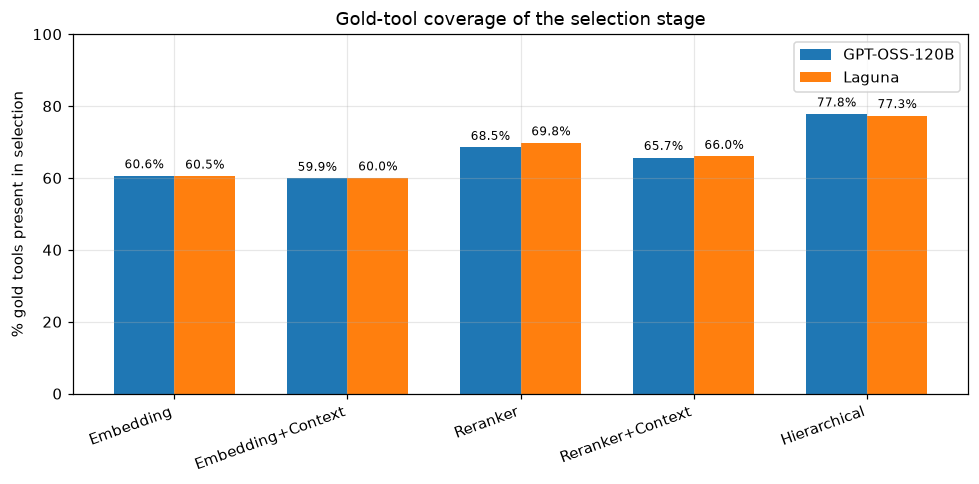

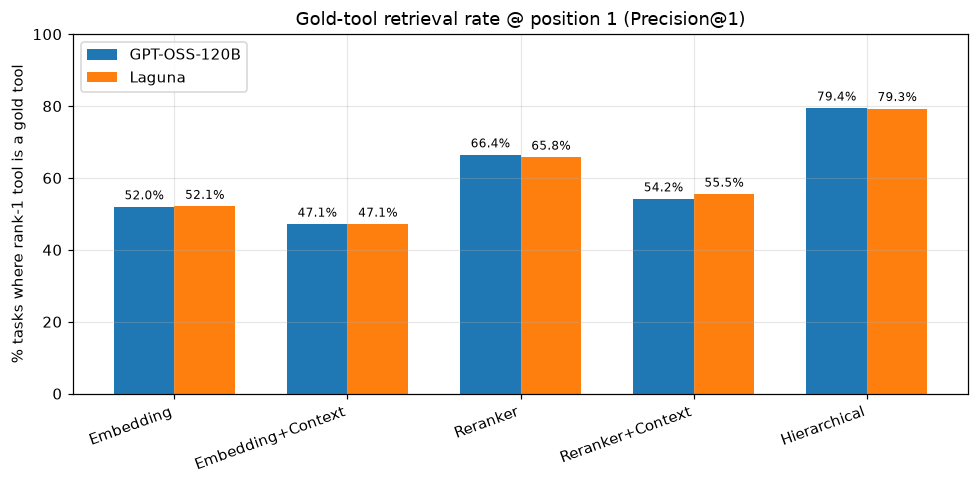

mean_gold_tool_coverage  precision_at_1
model  strategy                                                  
120B   embedding                         0.605946        0.519531
       embedding_context                 0.598720        0.471354
       hierarchical                      0.777886        0.794271
       reranker                          0.684766        0.664062
       reranker_context                  0.656814        0.541667
Laguna embedding                         0.604970        0.520833
       embedding_context                 0.600022        0.471354
       hierarchical                      0.773329        0.792969
       reranker                          0.697569        0.657552
       reranker_context                  0.659852        0.554688

In [15]:
selection_strategies = [s for s in STRATEGIES if s != "in_context"]
coverage_rows = []
for m in MODELS:
    for s in selection_strategies:
        selection = all_data[m][s]["selection"]
        selection_ranked = all_data[m][s]["selection_ranked"]
        for key, gold in gold_index.items():
            gold_tools = set(gold["gold_tools_unique"])
            if not gold_tools:
                continue  # Chat/no-tool tasks have nothing to cover
            selected = selection.get(key, set())
            top1 = next(iter(selection_ranked.get(key, [])), None)
            coverage_rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "coverage": len(gold_tools & selected) / len(gold_tools),
                "top1_hit": bool(top1 is not None and top1 in gold_tools),
            })
coverage_df = pd.DataFrame(coverage_rows)
coverage_summary = coverage_df.groupby(["model", "strategy"])["coverage"].mean()
top1_summary = coverage_df.groupby(["model", "strategy"])["top1_hit"].mean()

categories = [STRATEGY_LABELS[s] for s in selection_strategies]
series = {m: [coverage_summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}
width = 0.35
x = range(len(categories))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("% gold tools present in selection")
ax.set_title("Gold-tool coverage of the selection stage")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

# Precision@1: was the single highest-ranked tool handed to the LLM a gold tool?
series_top1 = {m: [top1_summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series_top1[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series_top1[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("% tasks where rank-1 tool is a gold tool")
ax.set_title("Gold-tool retrieval rate @ position 1 (Precision@1)")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

coverage_summary.rename("mean_gold_tool_coverage").to_frame().join(
    top1_summary.rename("precision_at_1")
)


## 7. Rank position of the executing LLM's tool calls

The selection stage runs fresh once per executor round (request). This section measures, for every individual round, where the LLM's first tool call in that round appears in that round's own ranked candidate list, separating retrieval from execution correctness. `in_context` is excluded because it has no ranked candidate list.

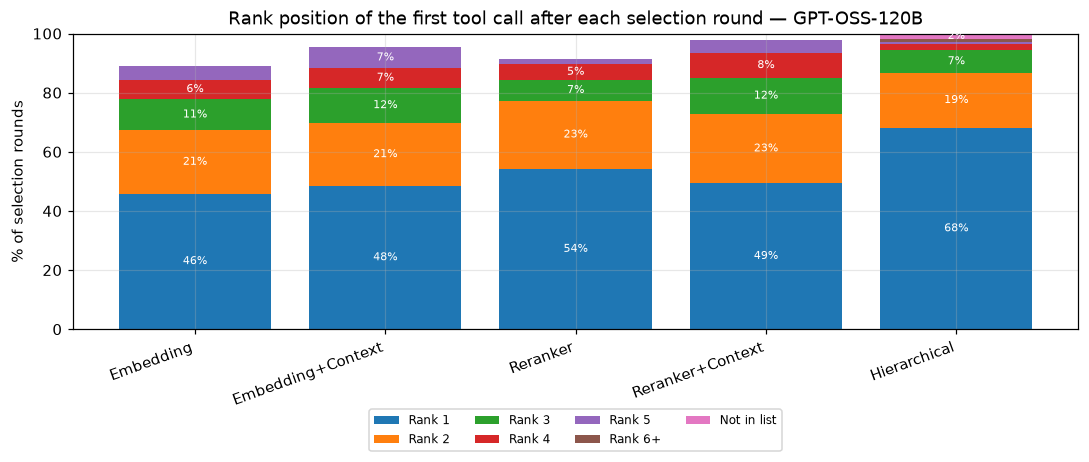

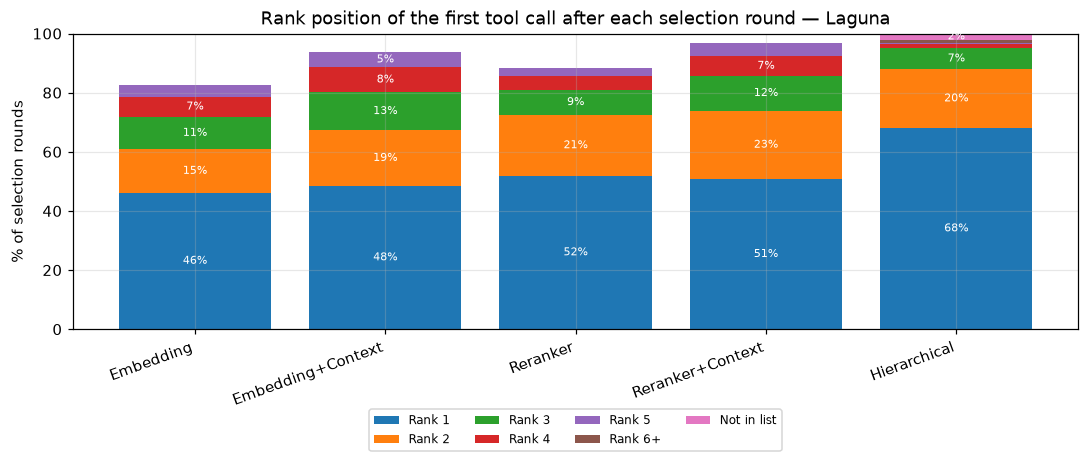

pct
model  strategy         rank             
120B   embedding        Rank 1       45.9
                        Rank 2       21.3
                        Not in list  11.1
                        Rank 3       10.7
                        Rank 4        6.5
...                                   ...
Laguna reranker_context Rank 2       23.2
                        Rank 3       11.8
                        Rank 4        6.6
                        Rank 5        4.6
                        Not in list   3.1

[62 rows x 1 columns]

In [16]:
rank_labels = ["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5", "Rank 6+", "Not in list"]


def rank_label(position: int | None) -> str:
    if position is None:
        return "Not in list"
    return rank_labels[position] if position < 5 else "Rank 6+"


def load_first_call_by_request(model: str, strategy: str) -> dict[str, str]:
    """The executing LLM's first tool call within each individual selection round (request_id)."""
    rows = read_jsonl(ROOT / RESULT_ROOTS[model] / strategy / "tool_call_logs.jsonl")
    rows.sort(key=lambda r: r.get("timestamp", 0))
    out = {}
    for row in rows:
        rid = row.get("request_id")
        if rid is None or rid in out:
            continue
        for tc in row.get("returned_tool_calls", []) or []:
            name = tc.get("name")
            if name:
                out[rid] = name
                break
    return out


first_call_rank_rows = []
for model in MODELS:
    for strategy in selection_strategies:
        selection_rows_by_request = {row["request_id"]: row for row in _load_final_selection_rows(model, strategy)}
        first_call_by_request = load_first_call_by_request(model, strategy)
        for request_id, sel_row in selection_rows_by_request.items():
            first_name = first_call_by_request.get(request_id)
            if first_name is None:
                continue  # this selection round never led to a tool call
            ranked = sel_row.get("selected_tool_names", []) or []
            position = ranked.index(first_name) if first_name in ranked else None
            first_call_rank_rows.append({
                "model": model,
                "strategy": strategy,
                "task_id": sel_row["test_entry_id"],
                "task_idx": sel_row["task_idx"],
                "request_id": request_id,
                "rank": rank_label(position),
            })

first_call_rank_df = pd.DataFrame(first_call_rank_rows)
for model in MODELS:
    counts = (
        first_call_rank_df[first_call_rank_df["model"] == model]
        .groupby(["strategy", "rank"]).size()
        .unstack("rank")
        .reindex(index=selection_strategies, columns=rank_labels, fill_value=0)
    )
    shares = counts.div(counts.sum(axis=1), axis=0).mul(100)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    bottom = [0.0] * len(selection_strategies)
    for rank in rank_labels:
        values = shares[rank].tolist()
        bars = ax.bar(range(len(selection_strategies)), values, bottom=bottom, label=rank)
        # Always label "Not in list" when non-zero so its rate is comparable across strategies.
        always_label = rank == "Not in list"
        ax.bar_label(
            bars,
            labels=[f"{value:.0f}%" if (value >= 5 or (always_label and value > 0)) else "" for value in values],
            label_type="center",
            fontsize=7,
            color="white",
        )
        bottom = [old + value for old, value in zip(bottom, values)]
    ax.set_xticks(range(len(selection_strategies)))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in selection_strategies], rotation=20, ha="right")
    ax.set_ylabel("% of selection rounds")
    ax.set_ylim(0, 100)
    ax.set_title(f"Rank position of the first tool call after each selection round — {MODEL_LABELS[model]}")
    ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.25))
    plt.tight_layout()
    plt.show()

first_call_rank_df.groupby(["model", "strategy"])["rank"].value_counts(normalize=True).mul(100).round(1).rename("pct").to_frame()

### 7b. When the rank-1 tool *is* gold, does the LLM actually execute it correctly?

Restricts to tasks where the top-ranked (rank-1) tool handed to the LLM is a gold tool (`top1_hit`
from section 6). Among only those tasks:

- **Name correct**: the WTB checker's `action_name_label` — did the LLM end up calling the right
  tool name(s) for the task?
- **Name + params correct**: the WTB checker's `action_arguments_label` — same, but the argument
  values must match too.

The gap between the two bars isolates parameter-initialization errors from tool-selection errors.
Note both labels are task-level (aggregated over every gold tool call in the task, not just the
first one), so for Multi-Tool tasks a "no" doesn't necessarily mean the rank-1 tool itself was
misused — a later step may be at fault instead.

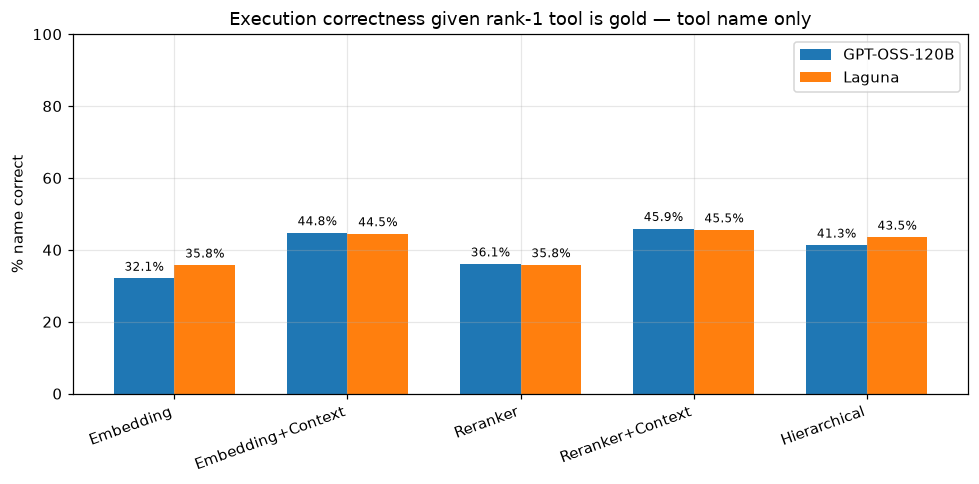

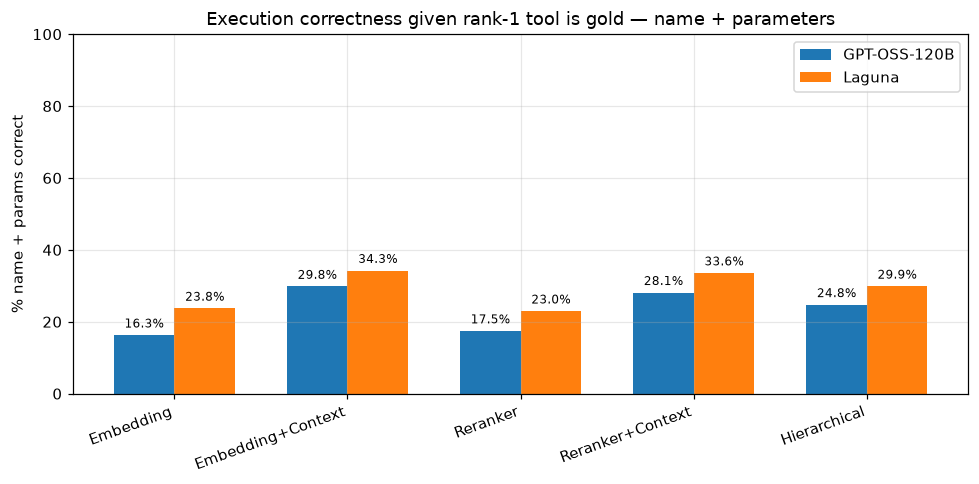

pct_name_correct  pct_name_and_params_correct  \
model  strategy                                                           
120B   embedding                  0.320802                     0.162907   
       embedding_context          0.447514                     0.298343   
       hierarchical               0.413115                     0.247541   
       reranker                   0.360784                     0.174510   
       reranker_context           0.459135                     0.281250   
Laguna embedding                  0.357500                     0.237500   
       embedding_context          0.444751                     0.342541   
       hierarchical               0.435140                     0.298851   
       reranker                   0.358416                     0.229703   
       reranker_context           0.455399                     0.335681   

                          n_tasks_rank1_is_gold  
model  strategy                                  
120B   embedding                            399  
       embedding_context                    362  
       hierarchical                         610  
       reranker                             510  
       reranker_context                     416  
Laguna embedding                            400  
       embedding_context                    362  
       hierarchical                         609  
       reranker                             505  
       reranker_context                     426

In [17]:
top1_gold_rows = []
for m in MODELS:
    for s in selection_strategies:
        tasks = all_data[m][s]["tasks"]
        selection_ranked = all_data[m][s]["selection_ranked"]
        for key, gold in gold_index.items():
            gold_tools = set(gold["gold_tools_unique"])
            if not gold_tools:
                continue  # Chat/no-tool tasks have no gold tool to rank
            ranked = selection_ranked.get(key, [])
            top1 = ranked[0] if ranked else None
            if top1 is None or top1 not in gold_tools:
                continue  # only tasks where the rank-1 selected tool is itself a gold tool
            task = tasks.get(key, {"name_correct": False, "args_correct": False})
            top1_gold_rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "name_correct": task["name_correct"],
                "args_correct": task["args_correct"],
            })
top1_gold_df = pd.DataFrame(top1_gold_rows)

name_summary = top1_gold_df.groupby(["model", "strategy"])["name_correct"].mean()
args_summary = top1_gold_df.groupby(["model", "strategy"])["args_correct"].mean()
n_summary = top1_gold_df.groupby(["model", "strategy"]).size()

categories = [STRATEGY_LABELS[s] for s in selection_strategies]
width = 0.35
x = range(len(categories))

for label, summary, title in [
    ("% name correct", name_summary, "Execution correctness given rank-1 tool is gold — tool name only"),
    ("% name + params correct", args_summary, "Execution correctness given rank-1 tool is gold — name + parameters"),
]:
    series = {m: [summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, m in enumerate(MODELS):
        offsets = [xi + i * width - width / 2 for xi in x]
        bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
        ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series[m]], padding=3, fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.set_ylabel(label)
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.legend()
    plt.tight_layout()
    plt.show()

name_summary.rename("pct_name_correct").to_frame().join(
    args_summary.rename("pct_name_and_params_correct")
).join(n_summary.rename("n_tasks_rank1_is_gold"))

### 7b (all tasks). Same execution-correctness comparison, without conditioning on retrieval success

The plot above only counts tasks where rank-1 already is a gold tool, and that subset's size differs
sharply by strategy (e.g. `hierarchical` reaches it on ~610/1024 tasks vs. ~400 for `embedding`), so
strategies with a higher Precision@1 pull in more, potentially harder, tasks into the comparison.
This cell instead reports `name_correct` / `args_correct` over **every** tool-required task
regardless of whether the selection stage got rank-1 right, giving every strategy the same
population and isolating the strategy's overall execution correctness from that subset-size effect.

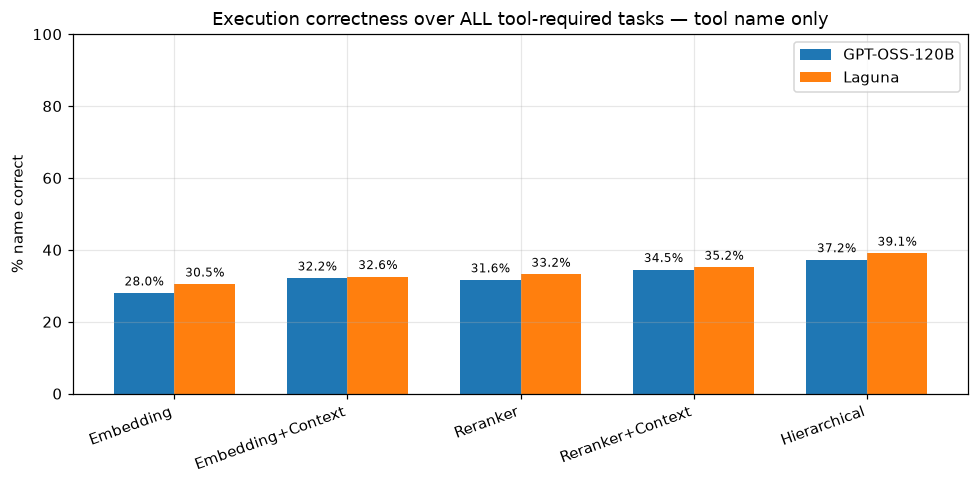

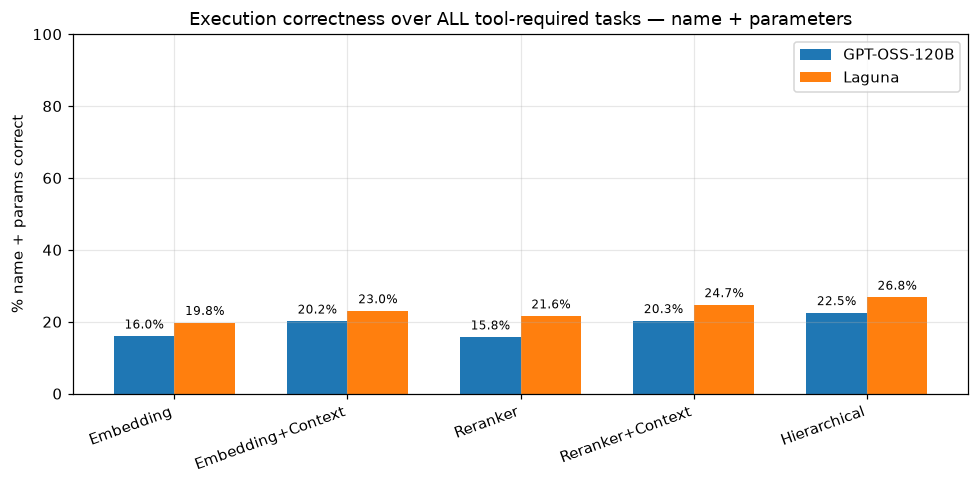

pct_name_correct_all_tasks  \
model  strategy                                        
120B   embedding                            0.279948   
       embedding_context                    0.321615   
       hierarchical                         0.372396   
       reranker                             0.316406   
       reranker_context                     0.345052   
Laguna embedding                            0.304688   
       embedding_context                    0.325521   
       hierarchical                         0.390625   
       reranker                             0.332031   
       reranker_context                     0.351562   

                          pct_name_and_params_correct_all_tasks  \
model  strategy                                                   
120B   embedding                                       0.160156   
       embedding_context                               0.201823   
       hierarchical                                    0.225260   
       reranker                                        0.157552   
       reranker_context                                0.203125   
Laguna embedding                                       0.197917   
       embedding_context                               0.230469   
       hierarchical                                    0.268229   
       reranker                                        0.216146   
       reranker_context                                0.247396   

                          n_tool_required_tasks  
model  strategy                                  
120B   embedding                            768  
       embedding_context                    768  
       hierarchical                         768  
       reranker                             768  
       reranker_context                     768  
Laguna embedding                            768  
       embedding_context                    768  
       hierarchical                         768  
       reranker                             768  
       reranker_context                     768

In [18]:
all_tool_task_rows = []
for m in MODELS:
    for s in selection_strategies:
        tasks = all_data[m][s]["tasks"]
        for key, gold in gold_index.items():
            if not gold["gold_tools_unique"]:
                continue  # Chat/no-tool tasks have no name/args label to compare
            task = tasks.get(key, {"name_correct": False, "args_correct": False})
            all_tool_task_rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "name_correct": task["name_correct"],
                "args_correct": task["args_correct"],
            })
all_tool_task_df = pd.DataFrame(all_tool_task_rows)

name_summary_all = all_tool_task_df.groupby(["model", "strategy"])["name_correct"].mean()
args_summary_all = all_tool_task_df.groupby(["model", "strategy"])["args_correct"].mean()
n_summary_all = all_tool_task_df.groupby(["model", "strategy"]).size()

categories = [STRATEGY_LABELS[s] for s in selection_strategies]
width = 0.35
x = range(len(categories))

for label, summary, title in [
    ("% name correct", name_summary_all, "Execution correctness over ALL tool-required tasks — tool name only"),
    ("% name + params correct", args_summary_all, "Execution correctness over ALL tool-required tasks — name + parameters"),
]:
    series = {m: [summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, m in enumerate(MODELS):
        offsets = [xi + i * width - width / 2 for xi in x]
        bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
        ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series[m]], padding=3, fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.set_ylabel(label)
    ax.set_title(title)
    ax.set_ylim(0, 100)
    ax.legend()
    plt.tight_layout()
    plt.show()

name_summary_all.rename("pct_name_correct_all_tasks").to_frame().join(
    args_summary_all.rename("pct_name_and_params_correct_all_tasks")
).join(n_summary_all.rename("n_tool_required_tasks"))

### 7d. Reranker approaches beat embedding on retrieval, but not always on accuracy — why?

`reranker`/`reranker_context` have higher gold-tool coverage and Precision@1 than their
`embedding`/`embedding_context` counterparts, yet for 120B their *overall task accuracy is lower*
(`reranker` 30.7% < `embedding` 31.9%; for Laguna it's the other way round, `reranker` 35.2% >
`embedding` 34.5% — the paradox is 120B-specific). The hierarchical explanation (higher reach into a
harder task mix) doesn't apply here since reranker's conditional name-correct rate is actually
*higher* than embedding's (36.1% vs 32.1%, section 7b). Three checks below isolate the real cause.

In [19]:
om = "120B"
pairs = [("embedding", "reranker"), ("embedding_context", "reranker_context")]

# Check 1: if reranker's own candidates were more "confusing", the LLM should follow the correct
# rank-1 tool LESS often than under embedding. It doesn't - it follows it slightly MORE often.
print("=== Given rank-1 tool is gold, does the LLM's first call follow it? (120B) ===")
follow_rows = []
for s in selection_strategies:
    tasks = all_data[om][s]["tasks"]
    selection_ranked = all_data[om][s]["selection_ranked"]
    tool_calls = all_data[om][s]["tool_calls"]
    for key, gold in gold_index.items():
        gold_tools = set(gold["gold_tools_unique"])
        if not gold_tools:
            continue
        ranked = selection_ranked.get(key, [])
        top1 = ranked[0] if ranked else None
        if top1 is None or top1 not in gold_tools:
            continue  # only the "rank-1 is gold" subset
        calls = tool_calls.get(key)
        first_call_name = calls[0]["name"] if calls else None
        if first_call_name is None:
            followed, strayed_in_list = None, None
        else:
            followed = first_call_name == top1
            strayed_in_list = (not followed) and (first_call_name in ranked)
        follow_rows.append({
            "strategy": s, "task_id": key[0], "task_idx": key[1],
            "followed_rank1": followed, "strayed_to_other_candidate": strayed_in_list,
        })
follow_df = pd.DataFrame(follow_rows)
summary = follow_df.groupby("strategy").agg(
    n=("followed_rank1", "size"),
    pct_followed_rank1=("followed_rank1", "mean"),
    pct_strayed_to_other_candidate=("strayed_to_other_candidate", "mean"),
)
print((summary * 100).round(1).assign(n=summary["n"]))

=== Given rank-1 tool is gold, does the LLM's first call follow it? (120B) ===
                     n pct_followed_rank1 pct_strayed_to_other_candidate
strategy                                                                
embedding          399          77.014925                      19.402985
embedding_context  362          78.769231                           20.0
hierarchical       610          92.934783                        6.34058
reranker           510          80.586907                      16.704289
reranker_context   416          81.298701                      17.922078


In [20]:
# Check 2: if reranker fully dropped the gold tool from its top-5 more often on misses, that would
# explain the accuracy loss without any LLM confusion. It doesn't - coverage is comparable/better.
print("=== When rank-1 is NOT gold, is the gold tool still present at all (rank 2-5), or fully dropped? (120B) ===")
miss_df = coverage_df[(coverage_df["model"] == om) & (~coverage_df["top1_hit"])]
print(miss_df.groupby("strategy").agg(
    n=("coverage", "size"),
    mean_coverage=("coverage", "mean"),
    pct_zero_coverage=("coverage", lambda c: (c == 0).mean()),

).round(3))

=== When rank-1 is NOT gold, is the gold tool still present at all (rank 2-5), or fully dropped? (120B) ===
                     n  mean_coverage  pct_zero_coverage
strategy                                                
embedding          369          0.403              0.439
embedding_context  406          0.422              0.426
hierarchical       158          0.608              0.158
reranker           258          0.432              0.407
reranker_context   352          0.474              0.361


In [21]:
# Check 3: is the LLM more easily fooled specifically by the WRONG rank-1 tool reranker introduces?
print("=== When rank-1 is WRONG, how often does the LLM still get fooled into calling that wrong rank-1 tool? (120B) ===")
fooled_rows = []
for s in selection_strategies:
    tasks = all_data[om][s]["tasks"]
    selection_ranked = all_data[om][s]["selection_ranked"]
    tool_calls = all_data[om][s]["tool_calls"]
    for key, gold in gold_index.items():
        gold_tools = set(gold["gold_tools_unique"])
        if not gold_tools:
            continue
        ranked = selection_ranked.get(key, [])
        top1 = ranked[0] if ranked else None
        if top1 is None or top1 in gold_tools:
            continue  # only the "rank-1 is wrong" subset
        calls = tool_calls.get(key)
        first_call_name = calls[0]["name"] if calls else None
        fooled_rows.append({
            "strategy": s,
            "gold_present_elsewhere": bool(gold_tools & set(ranked[1:])),
            "called_wrong_rank1": first_call_name == top1,
        })
fooled_df = pd.DataFrame(fooled_rows)
print(fooled_df.groupby("strategy").agg(
    n=("called_wrong_rank1", "size"),
    pct_gold_present_at_rank_2plus=("gold_present_elsewhere", "mean"),
    pct_llm_still_calls_wrong_rank1=("called_wrong_rank1", "mean"),
).round(3))

=== When rank-1 is WRONG, how often does the LLM still get fooled into calling that wrong rank-1 tool? (120B) ===
                     n  pct_gold_present_at_rank_2plus  \
strategy                                                 
embedding          367                           0.523   
embedding_context  402                           0.572   
hierarchical       157                           0.828   
reranker           258                           0.543   
reranker_context   351                           0.638   

                   pct_llm_still_calls_wrong_rank1  
strategy                                            
embedding                                    0.074  
embedding_context                            0.082  
hierarchical                                 0.178  
reranker                                     0.101  
reranker_context                             0.066  


In [22]:
# Check 4 (the decisive one): pair every task by what BOTH strategies did, so "harder subset"
# composition effects (the hierarchical explanation) are controlled for by construction.
def top1_hit_and_correct(model: str, strategy: str) -> dict[tuple[str, int], tuple[bool, bool]]:
    tasks = all_data[model][strategy]["tasks"]
    selection_ranked = all_data[model][strategy]["selection_ranked"]
    out = {}
    for key, gold in gold_index.items():
        gold_tools = set(gold["gold_tools_unique"])
        if not gold_tools:
            continue
        ranked = selection_ranked.get(key, [])
        top1 = ranked[0] if ranked else None
        hit = top1 is not None and top1 in gold_tools
        task = tasks.get(key, {"correct": False})
        out[key] = (hit, task["correct"])
    return out


print("=== Paired same-task comparison: does reranker actively lose tasks embedding still wins? (120B) ===")
for emb_s, rer_s in pairs:
    e_data = top1_hit_and_correct(om, emb_s)
    r_data = top1_hit_and_correct(om, rer_s)
    common = set(e_data) & set(r_data)

    both_hit = [k for k in common if e_data[k][0] and r_data[k][0]]
    emb_only_hit = [k for k in common if e_data[k][0] and not r_data[k][0]]
    rer_only_hit = [k for k in common if not e_data[k][0] and r_data[k][0]]
    both_miss = [k for k in common if not e_data[k][0] and not r_data[k][0]]

    def rate(keys, data):
        return sum(data[k][1] for k in keys) / len(keys) if keys else float("nan")

    print(f"--- {emb_s} vs {rer_s} ---")
    print(f"  BOTH rank-1 correct        : n={len(both_hit):4d}  acc({emb_s})={rate(both_hit, e_data):.3f}  acc({rer_s})={rate(both_hit, r_data):.3f}")
    print(f"  ONLY {emb_s} rank-1 correct (reranker demoted the right tool) : n={len(emb_only_hit):4d}  "
          f"acc({emb_s})={rate(emb_only_hit, e_data):.3f}  acc({rer_s})={rate(emb_only_hit, r_data):.3f}")
    print(f"  ONLY {rer_s} rank-1 correct (reranker promoted the right tool): n={len(rer_only_hit):4d}  "
          f"acc({emb_s})={rate(rer_only_hit, e_data):.3f}  acc({rer_s})={rate(rer_only_hit, r_data):.3f}")
    print(f"  BOTH rank-1 wrong          : n={len(both_miss):4d}  acc({emb_s})={rate(both_miss, e_data):.3f}  acc({rer_s})={rate(both_miss, r_data):.3f}")

    print()

=== Paired same-task comparison: does reranker actively lose tasks embedding still wins? (120B) ===
--- embedding vs reranker ---
  BOTH rank-1 correct        : n= 364  acc(embedding)=0.170  acc(reranker)=0.170
  ONLY embedding rank-1 correct (reranker demoted the right tool) : n=  35  acc(embedding)=0.086  acc(reranker)=0.086
  ONLY reranker rank-1 correct (reranker promoted the right tool): n= 146  acc(embedding)=0.164  acc(reranker)=0.185
  BOTH rank-1 wrong          : n= 223  acc(embedding)=0.152  acc(reranker)=0.130

--- embedding_context vs reranker_context ---
  BOTH rank-1 correct        : n= 314  acc(embedding_context)=0.315  acc(reranker_context)=0.315
  ONLY embedding_context rank-1 correct (reranker demoted the right tool) : n=  48  acc(embedding_context)=0.188  acc(reranker_context)=0.167
  ONLY reranker_context rank-1 correct (reranker promoted the right tool): n= 102  acc(embedding_context)=0.167  acc(reranker_context)=0.176
  BOTH rank-1 wrong          : n= 304  acc(emb

**Finding**: on the tasks where BOTH strategies fail to rank the gold tool first (`BOTH rank-1
wrong` — the single largest bucket, n=223/258 for 120B), 120B's execution accuracy is *lower* under
`reranker` than under `embedding` on the *exact same tasks* (13.0% vs 15.2% for plain; roughly level
for the `_context` variant). Since the task and its intrinsic difficulty are identical here, this
isn't a reach/composition effect like `hierarchical` — it means the specific wrong candidates the
cross-encoder substitutes in are, for GPT-OSS-120B, more actively misleading than embedding's wrong
candidates. Combined with reranker's much larger "both wrong" bucket (it still misses rank-1 on
~1/3 of tasks despite better Precision@1 overall), this is what erodes its retrieval advantage.
Crucially, this reruns the *opposite* way for Laguna below — confirming the effect is specific to
how the GPT-OSS-120B executing model handles the reranker's harder, more semantically-plausible
distractors, not an inherent flaw of reranking itself.

In [23]:
print("=== Same paired comparison for Laguna (robustness check) ===")
for m in ["Laguna"]:
    for emb_s, rer_s in pairs:
        e_data = top1_hit_and_correct(m, emb_s)
        r_data = top1_hit_and_correct(m, rer_s)
        common = set(e_data) & set(r_data)
        both_hit = [k for k in common if e_data[k][0] and r_data[k][0]]
        emb_only_hit = [k for k in common if e_data[k][0] and not r_data[k][0]]
        rer_only_hit = [k for k in common if not e_data[k][0] and r_data[k][0]]
        both_miss = [k for k in common if not e_data[k][0] and not r_data[k][0]]

        def rate(keys, data):
            return sum(data[k][1] for k in keys) / len(keys) if keys else float("nan")

        print(f"--- {m}: {emb_s} vs {rer_s} ---")
        print(f"  BOTH rank-1 correct : n={len(both_hit):4d}  acc({emb_s})={rate(both_hit, e_data):.3f}  acc({rer_s})={rate(both_hit, r_data):.3f}")
        print(f"  ONLY {emb_s} correct: n={len(emb_only_hit):4d}  acc({emb_s})={rate(emb_only_hit, e_data):.3f}  acc({rer_s})={rate(emb_only_hit, r_data):.3f}")
        print(f"  ONLY {rer_s} correct: n={len(rer_only_hit):4d}  acc({emb_s})={rate(rer_only_hit, e_data):.3f}  acc({rer_s})={rate(rer_only_hit, r_data):.3f}")
        print(f"  BOTH rank-1 wrong   : n={len(both_miss):4d}  acc({emb_s})={rate(both_miss, e_data):.3f}  acc({rer_s})={rate(both_miss, r_data):.3f}")
        print()

=== Same paired comparison for Laguna (robustness check) ===
--- Laguna: embedding vs reranker ---
  BOTH rank-1 correct : n= 356  acc(embedding)=0.242  acc(reranker)=0.236
  ONLY embedding correct: n=  44  acc(embedding)=0.205  acc(reranker)=0.227
  ONLY reranker correct: n= 149  acc(embedding)=0.168  acc(reranker)=0.215
  BOTH rank-1 wrong   : n= 219  acc(embedding)=0.146  acc(reranker)=0.183

--- Laguna: embedding_context vs reranker_context ---
  BOTH rank-1 correct : n= 316  acc(embedding_context)=0.361  acc(reranker_context)=0.364
  ONLY embedding_context correct: n=  46  acc(embedding_context)=0.217  acc(reranker_context)=0.174
  ONLY reranker_context correct: n= 110  acc(embedding_context)=0.191  acc(reranker_context)=0.255
  BOTH rank-1 wrong   : n= 296  acc(embedding_context)=0.108  acc(reranker_context)=0.132



## 8. Single-task deep dive

Compare, for one task, the gold trajectory against what each strategy actually selected, called and
answered. Change `TASK_ID` / `TASK_IDX` below to inspect a different task; use the `unique_wins` /
`coverage_df` tables above to find interesting candidates (e.g. `sorted(unique_wins["hierarchical"])`).


In [24]:
def show_task_comparison(model: str, task_id: str, task_idx: int, strategies: list[str] = STRATEGIES):
    key = (task_id, task_idx)
    gold = gold_index.get(key)
    if gold is None:
        print(f"No such task: {key}")
        return

    print(f"### [{MODEL_LABELS[model]}] {task_id}[{task_idx}]  ·  {gold['task_type']}  ·  {gold['turn_type']}"
          + (f" / {gold['turn_subtype']}" if gold["turn_subtype"] else ""))
    print(f"Query: {gold['query']}\n")

    print("--- Gold trajectory ---")
    for a in gold["gold_actions"]:
        name = a.get("action", {}).get("name")
        args = a.get("action", {}).get("arguments")
        if name == "prepare_to_answer":
            print(f"  => final answer: {a.get('observation')}")
        else:
            print(f"  call {name}({args})")
    print()

    for s in strategies:
        task = all_data[model][s]["tasks"].get(key, {})
        selected = sorted(all_data[model][s]["selection"].get(key, set()))
        executed = all_data[model][s]["tool_calls"].get(key, [])
        print(f"--- {STRATEGY_LABELS[s]} ({'CORRECT' if task.get('correct') else 'INCORRECT'}"
              f"{', optimal' if task.get('optimal') else ''}) ---")
        if selected:
            print(f"  selected tools : {selected}")
        for call in executed:
            print(f"  called         : {call['name']}({call['arguments']})")
        if task.get("final_answer"):
            print(f"  final answer   : {task['final_answer']}")
        print()


# Example: first task of the first benchmark session, for the 120B model
show_task_comparison("120B", "wild_tool_bench_7", 0)


### [GPT-OSS-120B] wild_tool_bench_7[0]  ·  Single-Tool  ·  First Turn
Query: Could you please provide some detailed information about Ontario, Canada? Such as its population, area, economic situation, etc.

--- Gold trajectory ---
  call getDivisionDetails({'countryCode': 'CA', 'divisionCode': 'ON'})
  => final answer: Here is detailed information about Ontario, Canada:

- **Name**: Ontario
- **Country Code**: CA
- **Administrative Division Code**: ON
- **Type**: Province
- **Population**: 14,734,014
- **Area**: 1,076,395 square kilometers
- **GDP**: $857 billion
- **Capital**: Toronto
- **Largest City**: Toronto
- **Official Language**: English
- **Description**: Ontario is the most populous province in Canada and the second-largest in area. Its capital and largest city is Toronto. Ontario has a highly developed economy, with its GDP ranking among the top in Canadian provinces.

I hope this information is helpful to you! If you have any other questions, please feel free to let me kno

## 9. Model comparison: 120B vs. Laguna

Directly compares the two executing models against each other, for every strategy:
overall task accuracy, session accuracy and average tokens/task.


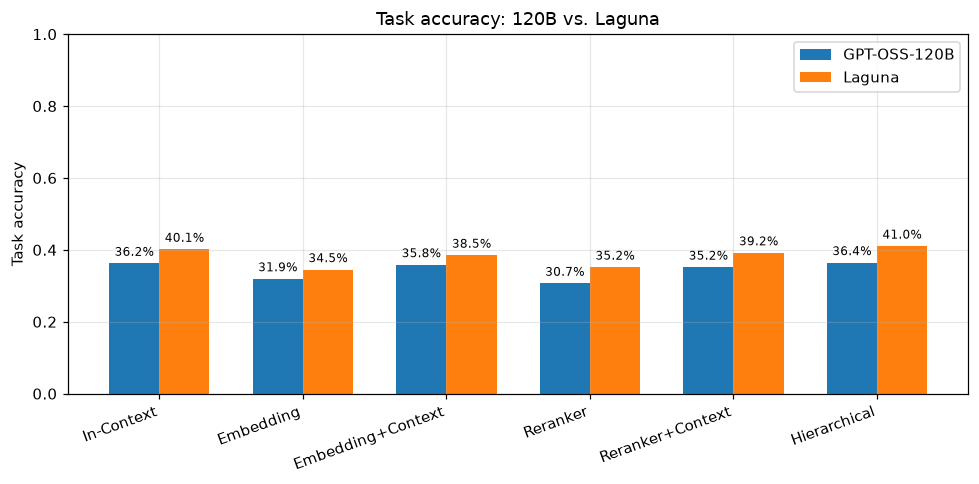

In [25]:
# Task accuracy per strategy, grouped by model
categories = [STRATEGY_LABELS[s] for s in STRATEGIES]
series = {
    m: [all_data[m][s]["metric"]["total_info"]["task"]["accuracy"] for s in STRATEGIES]
    for m in MODELS
}
width = 0.35
x = range(len(categories))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("Task accuracy")
ax.set_ylim(0, max(1.0, max(v for vals in series.values() for v in vals) * 1.15))
ax.set_title("Task accuracy: 120B vs. Laguna")
ax.legend()
plt.tight_layout()
plt.show()


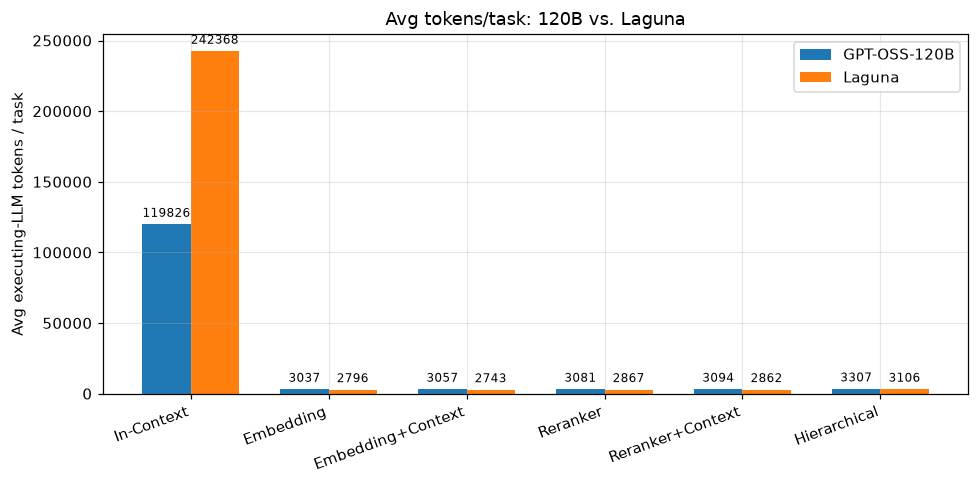

In [26]:
# Avg LLM tokens/task per strategy, grouped by model
series = {m: [token_summary.loc[(m, s), "avg_llm_tokens"] for s in STRATEGIES] for m in MODELS}

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.0f}" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("Avg executing-LLM tokens / task")
ax.set_title("Avg tokens/task: 120B vs. Laguna")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Improvement Strategies: ToolReAGT

This section restores the dedicated ToolReAGT analysis for the 120B run, including official metrics and retrieval-to-execution diagnostics.

In [27]:
toolreagt_metric_path = ROOT / "score" / "120B_toolreagt" / "langgraph" / "Wild-Tool-Bench_metric.json"
toolreagt_score_path = ROOT / "score" / "120B_toolreagt" / "langgraph" / "Wild-Tool-Bench_score.jsonl"

with open(toolreagt_metric_path, encoding="utf-8") as file:
    toolreagt_metric = json.load(file)
toolreagt_score_rows = read_jsonl(toolreagt_score_path)

print(f"Loaded ToolReAGT metric file: {toolreagt_metric_path}")
print(f"Task accuracy: {toolreagt_metric['total_info']['task']['accuracy']:.2%}")
print(f"Session accuracy: {toolreagt_metric['total_info']['session']['accuracy']:.2%}")

toolreagt_summary = pd.DataFrame({
    "metric_block": ["task", "session"],
    "accuracy": [
        toolreagt_metric["total_info"]["task"]["accuracy"],
        toolreagt_metric["total_info"]["session"]["accuracy"],
    ],
    "correct_count": [
        toolreagt_metric["total_info"]["task"]["correct_count"],
        toolreagt_metric["total_info"]["session"]["correct_count"],
    ],
    "total_count": [
        toolreagt_metric["total_info"]["task"]["total_count"],
        toolreagt_metric["total_info"]["session"]["total_count"],
    ],
})
display(toolreagt_summary)

Loaded ToolReAGT metric file: /home/aherrman/ToolSelectionBenchmark/wild-tool-bench/score/120B_toolreagt/langgraph/Wild-Tool-Bench_metric.json
Task accuracy: 32.91%
Session accuracy: 1.56%


,metric_block,accuracy,correct_count,total_count
0,task,0.329102,337,1024
1,session,0.015625,4,256


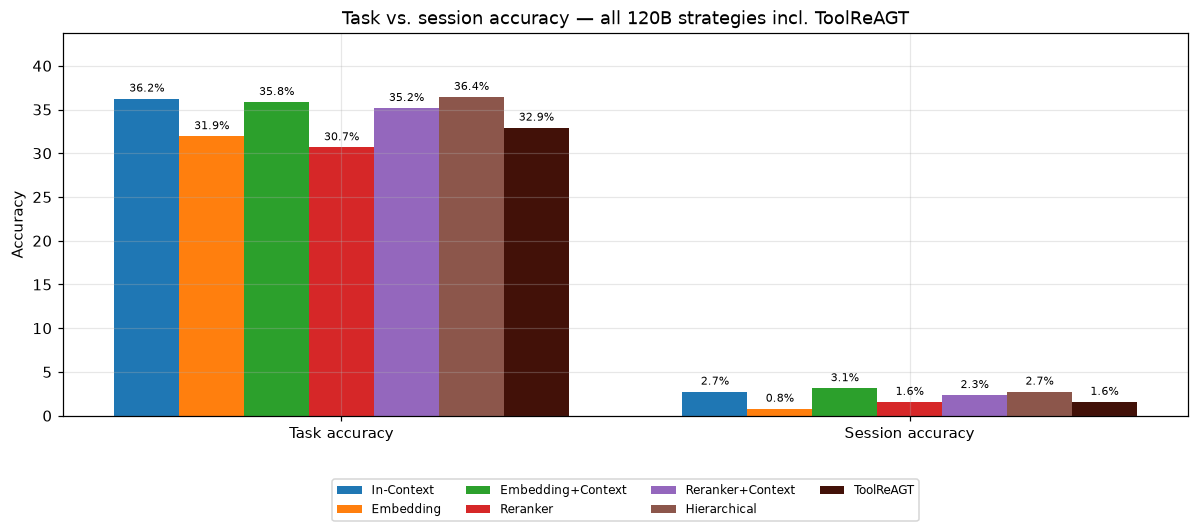

In [28]:
# Task vs. session accuracy for ToolReAGT in context with every other 120B strategy.
compare_strategies_120b = STRATEGIES + ["toolreagt"]
compare_colors = {**COLORS, "toolreagt": "#421108"}
compare_display_labels = {**STRATEGY_LABELS, "toolreagt": "ToolReAGT"}

categories = ["Task accuracy", "Session accuracy"]
series = {
    s: [
        all_data["120B"][s]["metric"]["total_info"]["task"]["accuracy"] * 100,
        all_data["120B"][s]["metric"]["total_info"]["session"]["accuracy"] * 100,
    ]
    for s in STRATEGIES
}
series["toolreagt"] = [
    toolreagt_metric["total_info"]["task"]["accuracy"] * 100,
    toolreagt_metric["total_info"]["session"]["accuracy"] * 100,
]

n_series = len(compare_strategies_120b)
width = 0.8 / n_series
x = range(len(categories))

fig, ax = plt.subplots(figsize=(11, 5))
for i, s in enumerate(compare_strategies_120b):
    offsets = [xi + i * width - 0.4 + width / 2 for xi in x]
    bars = ax.bar(offsets, series[s], width=width, label=compare_display_labels[s], color=compare_colors[s])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series[s]], padding=3, fontsize=7)
ax.set_xticks(list(x))
ax.set_xticklabels(categories)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, max(v for vals in series.values() for v in vals) * 1.2)
ax.set_title("Task vs. session accuracy — all 120B strategies incl. ToolReAGT")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.show()

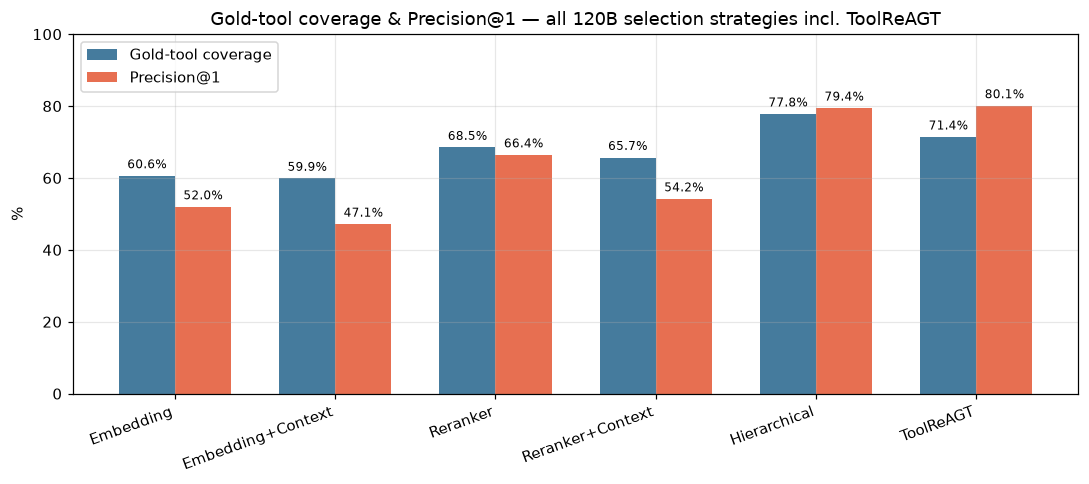

,strategy,mean_gold_tool_coverage_pct,precision_at_1_pct
0,Embedding,60.594618,51.953125
1,Embedding+Context,59.871962,47.135417
2,Reranker,68.476562,66.406250
3,Reranker+Context,65.681424,54.166667
4,Hierarchical,77.788628,79.427083
5,ToolReAGT,71.382378,80.078125


In [29]:
# Gold-tool coverage & Precision@1 for ToolReAGT in context with every other 120B selection strategy.
toolreagt_selection_path = ROOT / "result_120B_v2" / "toolreagt" / "tool_selection_logs.jsonl"


def load_toolreagt_selection_ranked() -> tuple[dict[tuple[str, int], set[str]], dict[tuple[str, int], list[str]]]:
    rows = read_jsonl(toolreagt_selection_path)
    rows.sort(key=lambda r: r.get("timestamp", 0))
    final_by_request = {}
    for row in rows:
        final_by_request[row.get("request_id")] = row
    union_selected = defaultdict(set)
    top1_ranked = {}
    for row in sorted(final_by_request.values(), key=lambda r: r.get("timestamp", 0)):
        key = (row["test_entry_id"], row["task_idx"])
        lst = row.get("selected_tool_names", []) or []
        union_selected[key].update(lst)
        if key not in top1_ranked:
            top1_ranked[key] = lst
    return union_selected, top1_ranked


toolreagt_selection, toolreagt_selection_ranked = load_toolreagt_selection_ranked()

toolreagt_coverage_rows = []
for key, gold in gold_index.items():
    gold_tools = set(gold["gold_tools_unique"])
    if not gold_tools:
        continue  # Chat/no-tool tasks have nothing to cover
    selected = toolreagt_selection.get(key, set())
    top1 = next(iter(toolreagt_selection_ranked.get(key, [])), None)
    toolreagt_coverage_rows.append({
        "task_id": key[0],
        "task_idx": key[1],
        "coverage": len(gold_tools & selected) / len(gold_tools),
        "top1_hit": bool(top1 is not None and top1 in gold_tools),
    })
toolreagt_coverage_df = pd.DataFrame(toolreagt_coverage_rows)

toolreagt_mean_coverage = toolreagt_coverage_df["coverage"].mean() * 100
toolreagt_precision_at_1 = toolreagt_coverage_df["top1_hit"].mean() * 100

compare_selection_categories = [STRATEGY_LABELS[s] for s in selection_strategies] + ["ToolReAGT"]
compare_coverage_values = [coverage_summary.loc[("120B", s)] * 100 for s in selection_strategies] + [toolreagt_mean_coverage]
compare_precision_values = [top1_summary.loc[("120B", s)] * 100 for s in selection_strategies] + [toolreagt_precision_at_1]

width = 0.35
x = range(len(compare_selection_categories))

fig, ax = plt.subplots(figsize=(10, 4.5))
bars1 = ax.bar([xi - width / 2 for xi in x], compare_coverage_values, width=width, label="Gold-tool coverage", color="#457B9D")
bars2 = ax.bar([xi + width / 2 for xi in x], compare_precision_values, width=width, label="Precision@1", color="#E76F51")
ax.bar_label(bars1, labels=[f"{v:.1f}%" for v in compare_coverage_values], padding=3, fontsize=8)
ax.bar_label(bars2, labels=[f"{v:.1f}%" for v in compare_precision_values], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(compare_selection_categories, rotation=20, ha="right")
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.set_title("Gold-tool coverage & Precision@1 — all 120B selection strategies incl. ToolReAGT")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    "strategy": compare_selection_categories,
    "mean_gold_tool_coverage_pct": compare_coverage_values,
    "precision_at_1_pct": compare_precision_values,
})

## 11. Why ToolReAGT can retrieve better but still perform worse

This section visualizes the retrieval-to-execution funnel to explain the apparent paradox:
- ToolReAGT often retrieves the gold tool at rank 1 more frequently than Embedding+Context.
- Yet its final end-to-end task accuracy can still be lower.

The key question is where loss happens after retrieval: executor call choice, multi-step drift, or argument/trajectory errors.

In [30]:
# Build a diagnostic table on common tasks for three strategies.
compare_strategies = ["in_context", "embedding_context", "toolreagt"]
compare_labels = {
    "in_context": STRATEGY_LABELS.get("in_context", "in_context"),
    "embedding_context": STRATEGY_LABELS.get("embedding_context", "embedding_context"),
    "toolreagt": "ToolReAGT",
}

strategy_cfg = {
    "in_context": {
        "score": ROOT / "score" / "120B_in_context" / "langgraph" / "Wild-Tool-Bench_score.jsonl",
        "selection_log": ROOT / "result_v3_120B" / "in_context" / "tool_selection_logs.jsonl",
        "metrics_summary": ROOT / "result_v3_120B" / "in_context" / "langgraph" / "Wild-Tool-Bench_metrics_summary.jsonl",
    },
    "embedding_context": {
        "score": ROOT / "score" / "120B_embedding_context" / "langgraph" / "Wild-Tool-Bench_score.jsonl",
        "selection_log": ROOT / "result_v3_120B" / "embedding_context" / "tool_selection_logs.jsonl",
        "metrics_summary": ROOT / "result_v3_120B" / "embedding_context" / "langgraph" / "Wild-Tool-Bench_metrics_summary.jsonl",
    },
    "toolreagt": {
        "score": ROOT / "score" / "120B_toolreagt" / "langgraph" / "Wild-Tool-Bench_score.jsonl",
        "selection_log": ROOT / "result_120B_v2" / "toolreagt" / "tool_selection_logs.jsonl",
        "metrics_summary": ROOT / "result_120B_v2" / "toolreagt" / "langgraph" / "Wild-Tool-Bench_metrics_summary.jsonl",
    },
}


def parse_score(path: Path) -> dict[tuple[str, int], dict]:
    rows = read_jsonl(path)
    out = {}
    for rec in rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            log = item.get("inference_log", {}) or {}
            step_keys = sorted(
                (k for k in log if str(k).startswith("step_")),
                key=lambda x: int(x.split("_")[1]),
            )
            calls = []
            for sk in step_keys:
                infer_out = log[sk].get("inference_output", {}) or {}
                for tc in infer_out.get("tool_calls", []) or []:
                    fn = tc.get("function", {}) or {}
                    if fn.get("name"):
                        calls.append(fn["name"])
            out[(eid, i)] = {
                "correct": item.get("label") == "correct",
                "name_correct": item.get("action_name_label") == "correct",
                "args_correct": item.get("action_arguments_label") == "correct",
                "calls": calls,
            }
    return out


def parse_selection(path: Path, is_toolreagt: bool) -> tuple[dict[tuple[str, int], set[str]], dict[tuple[str, int], list[str]]]:
    if not path.exists():
        return defaultdict(set), {}

    rows = read_jsonl(path)
    rows.sort(key=lambda r: r.get("timestamp", 0))

    # keep final row per request_id (last stage wins)
    final_by_request = {}
    for row in rows:
        final_by_request[row.get("request_id")] = row

    union_selected = defaultdict(set)
    top1_ranked = {}
    for row in final_by_request.values():
        key = (row["test_entry_id"], row["task_idx"])
        lst = row.get("selected_tool_names", []) or []
        union_selected[key].update(lst)
        if key not in top1_ranked:
            top1_ranked[key] = lst

    return union_selected, top1_ranked


def parse_steps(path: Path) -> dict[tuple[str, int], int]:
    rows = read_jsonl(path)
    out = {}
    for rec in rows:
        eid = rec["id"]
        for pt in rec["metrics"].get("per_task", []):
            out[(eid, pt["task_idx"])] = int(pt.get("steps", 0) or 0)
    return out


parsed = {}
for s in compare_strategies:
    cfg = strategy_cfg[s]
    parsed[s] = {}
    parsed[s]["tasks"] = parse_score(cfg["score"])
    sel_union, sel_ranked = parse_selection(cfg["selection_log"], is_toolreagt=(s == "toolreagt"))
    parsed[s]["selection"] = sel_union
    parsed[s]["selection_ranked"] = sel_ranked
    parsed[s]["steps"] = parse_steps(cfg["metrics_summary"])

# Kept for backward compatibility with the statistical-comparison section below.
toolreagt_tasks = parsed["toolreagt"]["tasks"]

common_keys_cmp = set(gold_index.keys())
for s in compare_strategies:
    common_keys_cmp &= set(parsed[s]["tasks"].keys())
common_keys_cmp = sorted(common_keys_cmp)

diag_rows_v2 = []
for s in compare_strategies:
    tasks = parsed[s]["tasks"]
    ranked = parsed[s]["selection_ranked"]
    selected = parsed[s]["selection"]

    for key in common_keys_cmp:
        gold_tools = set(gold_index[key]["gold_tools_unique"])
        has_gold_tool = len(gold_tools) > 0

        task = tasks.get(key, {})
        calls = task.get("calls", []) or []
        first_call = calls[0] if calls else None

        ranked_lst = ranked.get(key, [])
        top1 = ranked_lst[0] if ranked_lst else None
        top1_gold = (top1 in gold_tools) if (has_gold_tool and top1 is not None) else None

        first_called_in_gold = (first_call in gold_tools) if (has_gold_tool and first_call is not None) else None
        any_called_in_gold = (len(set(calls) & gold_tools) > 0) if has_gold_tool else None

        # For in_context there is no explicit selection stage; treat this as not applicable.
        if s == "in_context":
            out_of_selection_rate = None
        else:
            sel_set = selected.get(key, set())
            calls_for_check = [c for c in calls if not (s == "toolreagt" and c == "tool_retreiver")]
            if len(calls_for_check) == 0:
                out_of_selection_rate = 0.0
            else:
                miss = sum(1 for c in calls_for_check if c not in sel_set)
                out_of_selection_rate = miss / len(calls_for_check)

        diag_rows_v2.append({
            "strategy": s,
            "strategy_label": compare_labels[s],
            "task_id": key[0],
            "task_idx": key[1],
            "task_type": gold_index[key]["task_type"],
            "turn_subtype": gold_index[key]["turn_subtype"],
            "layer": gold_index[key]["layer"],
            "has_gold_tool": has_gold_tool,
            "correct": bool(task.get("correct", False)),
            "name_correct": bool(task.get("name_correct", False)),
            "args_correct": bool(task.get("args_correct", False)),
            "top1_gold": top1_gold,
            "first_called_in_gold": first_called_in_gold,
            "any_called_in_gold": any_called_in_gold,
            "no_tool_call": (len(calls) == 0),
            "out_of_selection_rate": out_of_selection_rate,
            "steps": parsed[s]["steps"].get(key, 0),
        })

diag_df_v2 = pd.DataFrame(diag_rows_v2)
print(f"Diagnostic rows: {len(diag_df_v2)} on common task keys: {len(common_keys_cmp)}")
diag_df_v2.head()

Diagnostic rows: 3072 on common task keys: 1024


,strategy,strategy_label,task_id,task_idx,task_type,turn_subtype,layer,has_gold_tool,correct,name_correct,args_correct,top1_gold,first_called_in_gold,any_called_in_gold,no_tool_call,out_of_selection_rate,steps
0,in_context,In-Context,wild_tool_bench_0,0,Single-Tool,NaN,0,True,True,True,True,None,True,True,False,NaN,2
1,in_context,In-Context,wild_tool_bench_0,1,Single-Tool,Partial Information,1,True,True,True,True,None,True,True,False,NaN,2
2,in_context,In-Context,wild_tool_bench_0,2,Mixed Multi-Tool,Partial Information,2,True,False,False,False,None,False,False,False,NaN,1
3,in_context,In-Context,wild_tool_bench_0,3,Chat,Coreferential Reference,3,False,True,True,True,None,None,None,True,NaN,1
4,in_context,In-Context,wild_tool_bench_1,0,Single-Tool,NaN,0,True,False,False,False,None,True,True,False,NaN,2


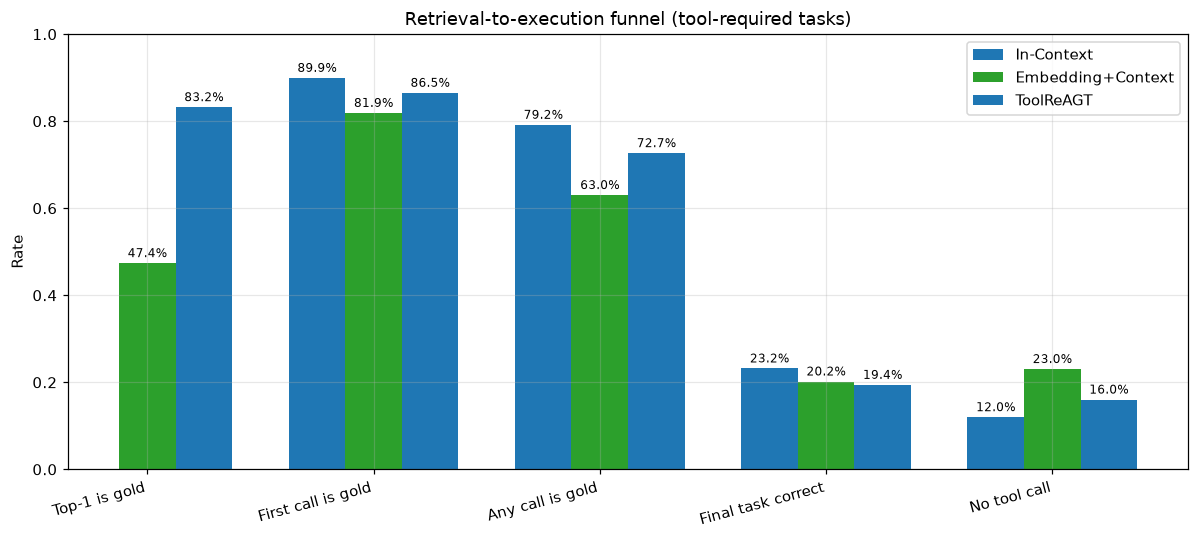

,strategy,top1_gold_rate,first_called_in_gold_rate,any_called_in_gold_rate,task_accuracy,no_tool_call_rate
0,In-Context,NaN,0.899408,0.791667,0.231771,0.119792
1,Embedding+Context,0.473822,0.818951,0.630208,0.201823,0.230469
2,ToolReAGT,0.832206,0.865116,0.726562,0.194010,0.160156


In [31]:
# Plot 1: Retrieval vs executor behavior vs final success (tool-required tasks only).
plot_base = diag_df_v2[diag_df_v2["has_gold_tool"]].copy()

funnel_rows = []
for s in compare_strategies:
    sub = plot_base[plot_base["strategy"] == s]
    funnel_rows.append({
        "strategy": compare_labels[s],
        "top1_gold_rate": sub["top1_gold"].mean() if sub["top1_gold"].notna().any() else float("nan"),
        "first_called_in_gold_rate": sub["first_called_in_gold"].mean(),
        "any_called_in_gold_rate": sub["any_called_in_gold"].mean(),
        "task_accuracy": sub["correct"].mean(),
        "no_tool_call_rate": sub["no_tool_call"].mean(),
    })

funnel_df = pd.DataFrame(funnel_rows)
long_funnel = funnel_df.melt(id_vars="strategy", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(11, 5))
metric_order = [
    "top1_gold_rate",
    "first_called_in_gold_rate",
    "any_called_in_gold_rate",
    "task_accuracy",
    "no_tool_call_rate",
]
metric_labels = {
    "top1_gold_rate": "Top-1 is gold",
    "first_called_in_gold_rate": "First call is gold",
    "any_called_in_gold_rate": "Any call is gold",
    "task_accuracy": "Final task correct",
    "no_tool_call_rate": "No tool call",
}

width = 0.25
x = list(range(len(metric_order)))
for i, s in enumerate(compare_strategies):
    values = [
        float(long_funnel[(long_funnel["strategy"] == compare_labels[s]) & (long_funnel["metric"] == m)]["value"].iloc[0])
        for m in metric_order
    ]
    offsets = [xi + i * width - width for xi in x]
    bars = ax.bar(offsets, values, width=width, label=compare_labels[s], color=COLORS.get(s, None))
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in values], fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metric_order], rotation=15, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Rate")
ax.set_title("Retrieval-to-execution funnel (tool-required tasks)")
ax.legend()
plt.tight_layout()
plt.show()

funnel_df

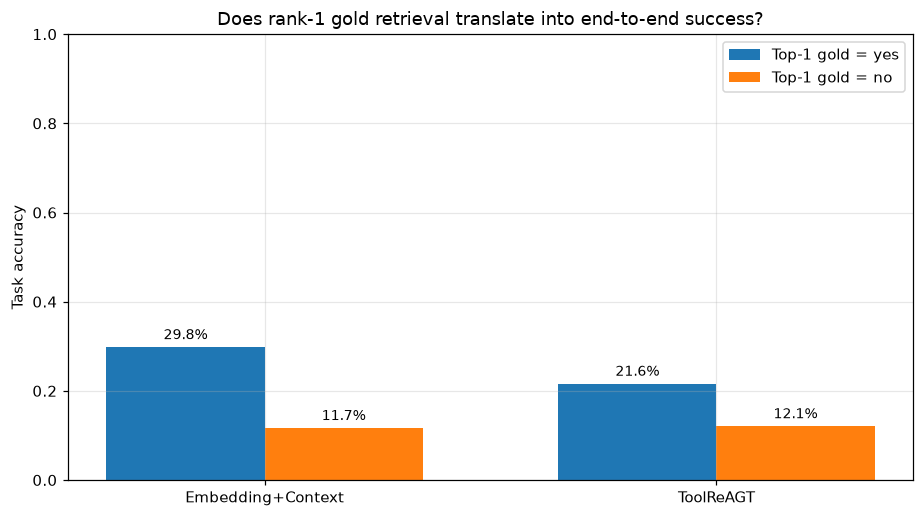

,strategy,condition,accuracy,count
0,Embedding+Context,Top-1 gold = yes,0.298343,362
1,Embedding+Context,Top-1 gold = no,0.116915,402
2,ToolReAGT,Top-1 gold = yes,0.216260,615
3,ToolReAGT,Top-1 gold = no,0.120968,124


In [32]:
# Plot 2: Conditional accuracy when the selector got rank-1 right vs wrong.
cond_rows = []
for s in ["embedding_context", "toolreagt"]:
    sub = plot_base[(plot_base["strategy"] == s) & (plot_base["top1_gold"].notna())].copy()
    hit = sub[sub["top1_gold"] == True]
    miss = sub[sub["top1_gold"] == False]
    cond_rows.append({
        "strategy": compare_labels[s],
        "condition": "Top-1 gold = yes",
        "accuracy": hit["correct"].mean() if len(hit) else float("nan"),
        "count": len(hit),
    })
    cond_rows.append({
        "strategy": compare_labels[s],
        "condition": "Top-1 gold = no",
        "accuracy": miss["correct"].mean() if len(miss) else float("nan"),
        "count": len(miss),
    })

cond_df = pd.DataFrame(cond_rows)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_order = ["Embedding+Context", "ToolReAGT"]
cond_order = ["Top-1 gold = yes", "Top-1 gold = no"]
width = 0.35
x = list(range(len(plot_order)))

for i, cond in enumerate(cond_order):
    vals = [
        cond_df[(cond_df["strategy"] == s) & (cond_df["condition"] == cond)]["accuracy"].iloc[0]
        for s in plot_order
    ]
    bars = ax.bar([xi + i * width - width / 2 for xi in x], vals, width=width, label=cond)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in vals], padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_order)
ax.set_ylabel("Task accuracy")
ax.set_ylim(0, 1)
ax.set_title("Does rank-1 gold retrieval translate into end-to-end success?")
ax.legend()
plt.tight_layout()
plt.show()

cond_df

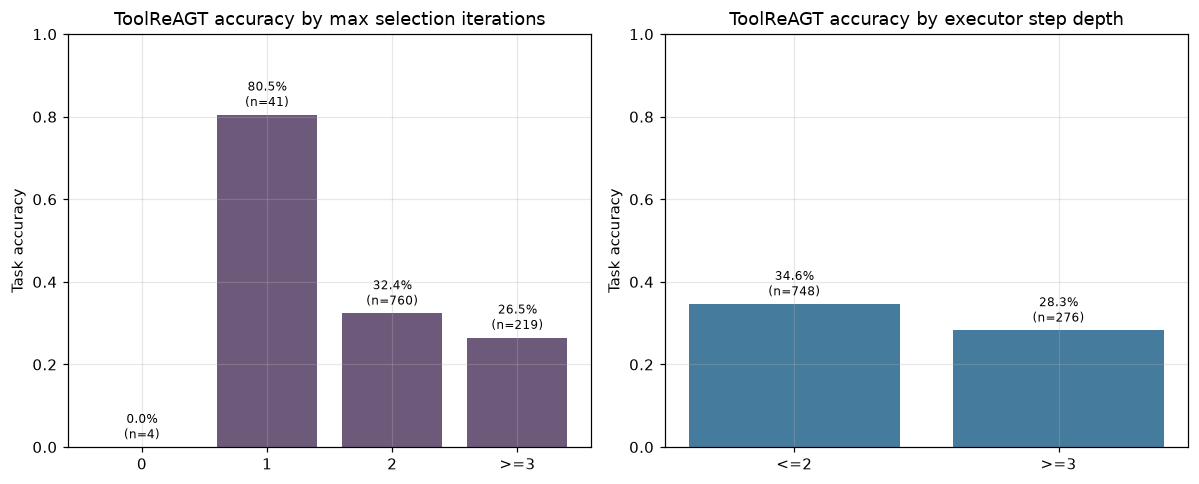

(                  acc    n
 iter_bucket               
 0            0.000000    4
 1            0.804878   41
 2            0.323684  760
 >=3          0.264840  219,
                   acc    n
 step_bucket               
 <=2          0.346257  748
 >=3          0.282609  276)

In [33]:
# Plot 3: ToolReAGT degradation with more selection iterations and more executor steps.
# Map max toolreagt selection iterations per task from tool_selection_logs.
tr_sel_rows = read_jsonl(ROOT / "result_120B_v2" / "toolreagt" / "tool_selection_logs.jsonl")
tr_sel_rows = [r for r in tr_sel_rows if r.get("strategy") == "toolreagt"]
tr_sel_rows.sort(key=lambda r: r.get("timestamp", 0))

final_by_req = {}
for r in tr_sel_rows:
    final_by_req[r.get("request_id")] = r

iter_by_task = {}
for r in final_by_req.values():
    key = (r["test_entry_id"], r["task_idx"])
    it = (r.get("metadata", {}) or {}).get("toolreagt_iterations")
    if isinstance(it, int):
        iter_by_task[key] = max(it, iter_by_task.get(key, 0))

tr = diag_df_v2[diag_df_v2["strategy"] == "toolreagt"].copy()
tr["iter_bucket"] = tr.apply(
    lambda row: "0" if iter_by_task.get((row["task_id"], row["task_idx"]), 0) == 0
    else ("1" if iter_by_task.get((row["task_id"], row["task_idx"]), 0) == 1
          else ("2" if iter_by_task.get((row["task_id"], row["task_idx"]), 0) == 2 else ">=3")),
    axis=1,
)
tr["step_bucket"] = tr["steps"].apply(lambda x: "<=2" if x <= 2 else ">=3")

iter_summary = tr.groupby("iter_bucket").agg(acc=("correct", "mean"), n=("correct", "size")).reindex(["0", "1", "2", ">=3"])
step_summary = tr.groupby("step_bucket").agg(acc=("correct", "mean"), n=("correct", "size")).reindex(["<=2", ">=3"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars = axes[0].bar(iter_summary.index.astype(str), iter_summary["acc"], color="#6D597A")
axes[0].bar_label(bars, labels=[f"{v:.1%}\n(n={int(n)})" if pd.notna(v) else "n/a" for v, n in zip(iter_summary["acc"], iter_summary["n"])], padding=3, fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Task accuracy")
axes[0].set_title("ToolReAGT accuracy by max selection iterations")

bars = axes[1].bar(step_summary.index.astype(str), step_summary["acc"], color="#457B9D")
axes[1].bar_label(bars, labels=[f"{v:.1%}\n(n={int(n)})" for v, n in zip(step_summary["acc"], step_summary["n"])], padding=3, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Task accuracy")
axes[1].set_title("ToolReAGT accuracy by executor step depth")

plt.tight_layout()
plt.show()

iter_summary, step_summary

## 12. Request-level join: selection output vs executor behavior

This section directly joins selection-stage outputs and executor tool calls per `request_id`.
It answers the exact question: does the executor call the tools that the selection strategy finally returns, and does that lead to correctness?

In [34]:
# Build request-level join for Embedding+Context and ToolReAGT.

def _score_correct_map(strategy: str) -> dict[tuple[str, int], bool]:
    if strategy == "toolreagt":
        path = ROOT / "score" / "120B_toolreagt" / "langgraph" / "Wild-Tool-Bench_score.jsonl"
    else:
        path = ROOT / "score" / f"120B_{strategy}" / "langgraph" / "Wild-Tool-Bench_score.jsonl"
    rows = read_jsonl(path)
    out = {}
    for rec in rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            out[(eid, i)] = item.get("label") == "correct"
    return out


def _request_join_for_strategy(strategy: str) -> pd.DataFrame:
    if strategy == "toolreagt":
        base = ROOT / "result_120B_v2" / "toolreagt"
    else:
        base = ROOT / "result_v3_120B" / strategy

    sel_rows = read_jsonl(base / "tool_selection_logs.jsonl")
    call_rows = read_jsonl(base / "tool_call_logs.jsonl")

    # Final selection result per request: keep last row for each request_id.
    sel_rows.sort(key=lambda r: r.get("timestamp", 0))
    final_sel = {}
    for r in sel_rows:
        final_sel[r.get("request_id")] = r

    # Tool calls per request in temporal order.
    call_rows.sort(key=lambda r: r.get("timestamp", 0))
    calls_by_req = defaultdict(list)
    for r in call_rows:
        rid = r.get("request_id")
        for tc in r.get("returned_tool_calls", []) or []:
            name = tc.get("name")
            if name:
                calls_by_req[rid].append(name)

    correct_map = _score_correct_map(strategy)

    rows = []
    for rid, sel in final_sel.items():
        key = (sel["test_entry_id"], sel["task_idx"])
        selected = sel.get("selected_tool_names", []) or []
        selected_set = set(selected)

        calls = calls_by_req.get(rid, [])
        # For ToolReAGT, internal retriever call is not the executor's final task call.
        if strategy == "toolreagt":
            calls = [c for c in calls if c != "tool_retreiver"]

        first_call = calls[0] if calls else None
        gold_tools = set(gold_index.get(key, {}).get("gold_tools_unique", []))
        has_gold = len(gold_tools) > 0

        rows.append({
            "strategy": strategy,
            "strategy_label": "ToolReAGT" if strategy == "toolreagt" else STRATEGY_LABELS.get(strategy, strategy),
            "request_id": rid,
            "task_id": key[0],
            "task_idx": key[1],
            "selected_tool_names": selected,
            "selected_count": len(selected),
            "first_executor_call": first_call,
            "executor_called_any": len(calls) > 0,
            "first_in_selected": (first_call in selected_set) if first_call is not None else False,
            "first_in_gold": (first_call in gold_tools) if (first_call is not None and has_gold) else None,
            "selected_contains_any_gold": (len(selected_set & gold_tools) > 0) if has_gold else None,
            "task_correct": bool(correct_map.get(key, False)),
            "has_gold_tool": has_gold,
            "toolreagt_iterations": (sel.get("metadata", {}) or {}).get("toolreagt_iterations") if strategy == "toolreagt" else None,
        })

    return pd.DataFrame(rows)


req_join_df = pd.concat(
    [
        _request_join_for_strategy("embedding_context"),
        _request_join_for_strategy("toolreagt"),
    ],
    ignore_index=True,
)

print(f"Request-level rows: {len(req_join_df)}")
req_join_df.head()

Request-level rows: 5391


,strategy,strategy_label,request_id,task_id,task_idx,selected_tool_names,selected_count,first_executor_call,executor_called_any,first_in_selected,first_in_gold,selected_contains_any_gold,task_correct,has_gold_tool,toolreagt_iterations
0,embedding_context,Embedding+Context,1d9d8d402d214b00bbd631d79a6ca747,wild_tool_bench_0,0,"[getFishingWeatherForecast, getStadiumWeather,...",5,getFishingWeatherForecast,True,True,False,False,False,True,None
1,embedding_context,Embedding+Context,7fa940ed7133479dae06721758b8123a,wild_tool_bench_0,1,"[getFishingWeatherForecast, getCityForecast, g...",5,getCityForecast,True,True,True,True,True,True,None
2,embedding_context,Embedding+Context,edbcce92fb7941c2a670c5151c900dd4,wild_tool_bench_0,1,"[getFishingWeatherForecast, getCityForecast, g...",5,NaN,False,False,None,True,True,True,None
3,embedding_context,Embedding+Context,1519207dfdd84171b2d469debed761dc,wild_tool_bench_0,2,"[getCityAQIForecast, getFishingWeatherForecast...",5,getCityAQIForecast,True,True,True,True,False,True,None
4,embedding_context,Embedding+Context,72a79b935f914278ac66f27b885c0b48,wild_tool_bench_0,2,"[getCityAQIForecast, getUVIndex, getFishingWea...",5,NaN,False,False,None,True,False,True,None


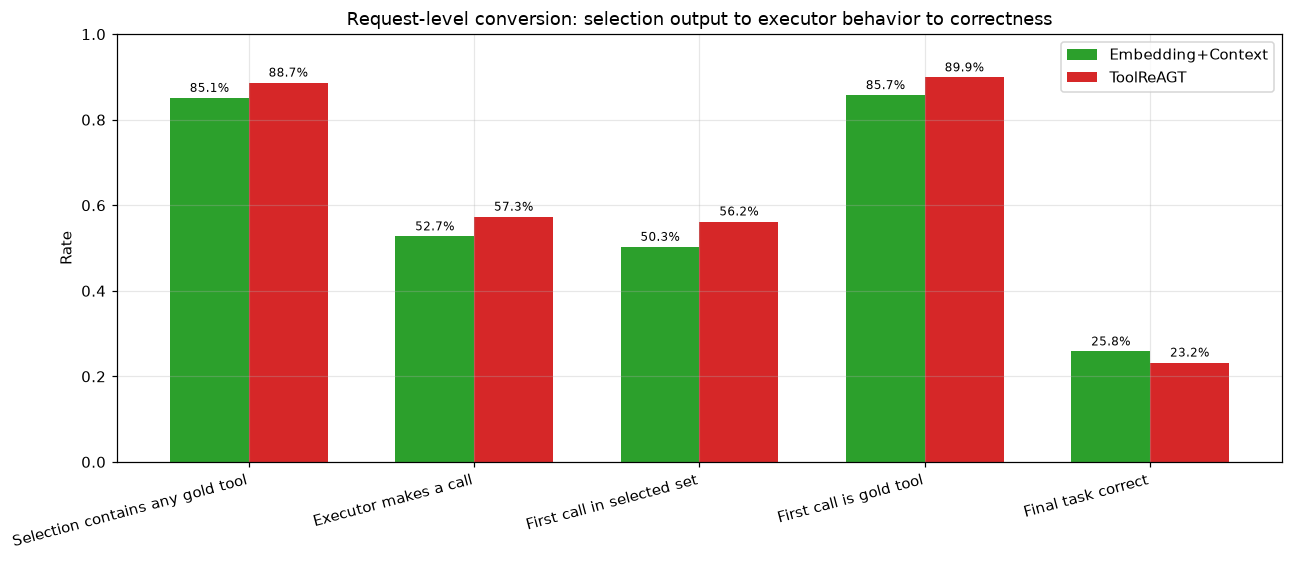

,strategy,selected_contains_any_gold,first_executor_call_exists,first_executor_call_in_selected,first_executor_call_is_gold,final_task_correct
0,Embedding+Context,0.850924,0.527132,0.502683,0.857466,0.258199
1,ToolReAGT,0.886682,0.573103,0.562032,0.898864,0.232172


In [35]:
# Plot the key conversion stages from selection to correctness.
plot_req = req_join_df[req_join_df["has_gold_tool"]].copy()

summary_rows = []
for s in ["embedding_context", "toolreagt"]:
    sub = plot_req[plot_req["strategy"] == s]
    summary_rows.append({
        "strategy": "ToolReAGT" if s == "toolreagt" else "Embedding+Context",
        "selected_contains_any_gold": sub["selected_contains_any_gold"].mean(),
        "first_executor_call_exists": sub["executor_called_any"].mean(),
        "first_executor_call_in_selected": sub["first_in_selected"].mean(),
        "first_executor_call_is_gold": sub["first_in_gold"].dropna().mean(),
        "final_task_correct": sub["task_correct"].mean(),
    })
summary_join_df = pd.DataFrame(summary_rows)

metric_order = [
    "selected_contains_any_gold",
    "first_executor_call_exists",
    "first_executor_call_in_selected",
    "first_executor_call_is_gold",
    "final_task_correct",
]
metric_labels = {
    "selected_contains_any_gold": "Selection contains any gold tool",
    "first_executor_call_exists": "Executor makes a call",
    "first_executor_call_in_selected": "First call in selected set",
    "first_executor_call_is_gold": "First call is gold tool",
    "final_task_correct": "Final task correct",
}

fig, ax = plt.subplots(figsize=(12, 5.2))
width = 0.35
x = list(range(len(metric_order)))
order = ["Embedding+Context", "ToolReAGT"]
palette = {"Embedding+Context": COLORS.get("embedding_context"), "ToolReAGT": COLORS.get("toolreagt", "#d62728")}

for i, name in enumerate(order):
    vals = [
        float(summary_join_df[summary_join_df["strategy"] == name][m].iloc[0])
        for m in metric_order
    ]
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, vals, width=width, label=name, color=palette[name])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in vals], fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metric_order], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Rate")
ax.set_title("Request-level conversion: selection output to executor behavior to correctness")
ax.legend()
plt.tight_layout()
plt.show()

summary_join_df

In [36]:
# Optional deep-dive table: rows where selection looked good but final answer was wrong.
paradox_df = plot_req[
    (plot_req["selected_contains_any_gold"] == True)
    & (plot_req["first_in_gold"] == True)
    & (plot_req["task_correct"] == False)
].copy()

print("Paradox cases (selection + first call looked right, but task still wrong):")
print(paradox_df.groupby("strategy_label").size())

paradox_df[[
    "strategy_label",
    "request_id",
    "task_id",
    "task_idx",
    "selected_tool_names",
    "first_executor_call",
    "task_correct",
    "toolreagt_iterations",
]].head(20)

Paradox cases (selection + first call looked right, but task still wrong):
strategy_label
Embedding+Context     523
ToolReAGT            1231
dtype: int64


,strategy_label,request_id,task_id,task_idx,selected_tool_names,first_executor_call,task_correct,toolreagt_iterations
3,Embedding+Context,1519207dfdd84171b2d469debed761dc,wild_tool_bench_0,2,"[getCityAQIForecast, getFishingWeatherForecast...",getCityAQIForecast,False,None
6,Embedding+Context,1a6c8c2d7b5c46e7b503e41d67e9bd5b,wild_tool_bench_1,0,"[getParliamentDebates, getDebateSchedule, sear...",getParliamentDebates,False,None
8,Embedding+Context,08ce8078e7824f7197d39404e666e075,wild_tool_bench_1,1,"[getParliamentDebates, getDebateSchedule, sear...",getParliamentDebates,False,None
17,Embedding+Context,abb389a3e1b44035bd3c93070dd31dad,wild_tool_bench_2,2,"[getBudgets, deleteBudgetCategory, createTrans...",syncTransactions,False,None
19,Embedding+Context,e7c0969696724670ae9c6edd3afcb226,wild_tool_bench_2,3,"[deleteBudgetCategory, getBudgets, getCategory...",updateTransaction,False,None
25,Embedding+Context,e5e7fcd375ba4f4cbae0b2f22c40626f,wild_tool_bench_3,2,"[getDetailedInfoByIP, getLocationByIP, listCur...",getLocationByIP,False,None
26,Embedding+Context,1a5e88e0c8574225a199533de2b3895e,wild_tool_bench_3,3,"[getDetailedInfoByIP, getLocationByIP, getISPI...",getLocationByIP,False,None
33,Embedding+Context,763f01e1f8dd4534bed12e30bc268780,wild_tool_bench_5,0,"[getRealtimeWeather, getUVIndex, getFishingWea...",getRealtimeWeather,False,None
37,Embedding+Context,cc92cc130ca24eb194d3d04492aae14a,wild_tool_bench_5,2,"[getAirportWeather, getNotamList, getAirportDe...",getAirportDelays,False,None
50,Embedding+Context,d481db29f83945ae954e3a8bbff95240,wild_tool_bench_7,0,"[getDivisionDetails, getProvinceArea, calculat...",getDivisionDetails,False,None


In [37]:
# Normalize the paradox: request multiplicity and conversion after a good first call.
conv_rows = []
for s in ["embedding_context", "toolreagt"]:
    sub = req_join_df[(req_join_df["strategy"] == s) & (req_join_df["has_gold_tool"])].copy()

    reqs_per_task = sub.groupby(["task_id", "task_idx"]).size()

    good_start = sub[(sub["first_in_gold"] == True) & (sub["executor_called_any"] == True)]
    conv_good_start = good_start["task_correct"].mean() if len(good_start) else float("nan")

    conv_rows.append({
        "strategy": "ToolReAGT" if s == "toolreagt" else "Embedding+Context",
        "request_rows": len(sub),
        "unique_tasks": int(sub[["task_id", "task_idx"]].drop_duplicates().shape[0]),
        "avg_requests_per_task": reqs_per_task.mean(),
        "median_requests_per_task": reqs_per_task.median(),
        "good_start_rows": len(good_start),
        "conversion_good_start_to_correct": conv_good_start,
    })

conv_df = pd.DataFrame(conv_rows)
conv_df

,strategy,request_rows,unique_tasks,avg_requests_per_task,median_requests_per_task,good_start_rows,conversion_good_start_to_correct
0,Embedding+Context,1677,764,2.195026,2.0,758,0.288918
1,ToolReAGT,3071,765,4.014379,4.0,1582,0.214918


## 13. Why good early tool picks still fail: failure-type breakdown

Even when the selector contains gold tools and the executor starts with a gold tool call, end-to-end success can fail later.
This breakdown separates failures into:
- wrong tool trajectory (name-level mismatch),
- wrong arguments with otherwise right tool names,
- downstream answer/composition issues despite name+arg labels being correct.

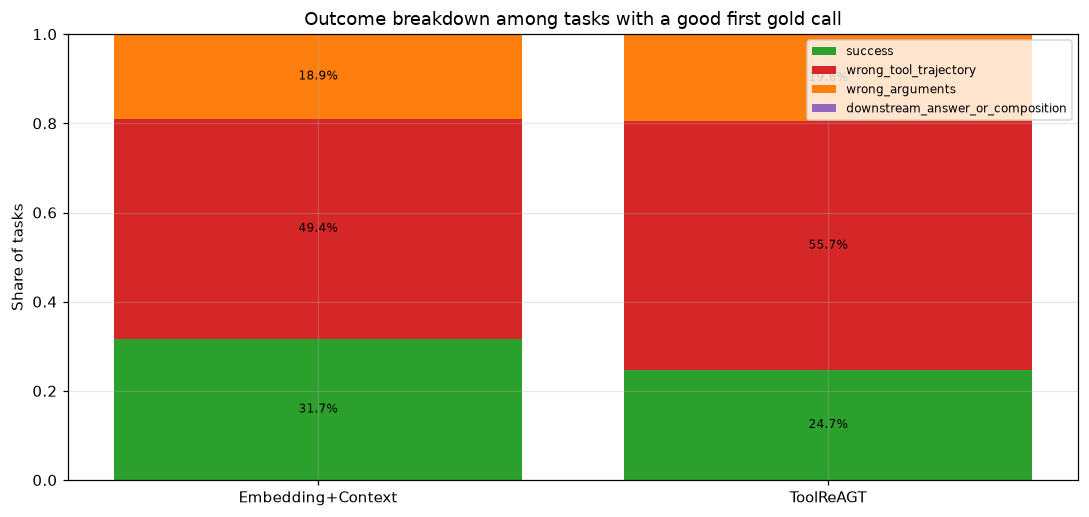

,strategy_label,failure_type,count,pct
0,Embedding+Context,success,154,0.316872
1,Embedding+Context,wrong_arguments,92,0.189300
2,Embedding+Context,wrong_tool_trajectory,240,0.493827
3,ToolReAGT,success,148,0.247492
4,ToolReAGT,wrong_arguments,117,0.195652
5,ToolReAGT,wrong_tool_trajectory,333,0.556856


In [38]:
# Failure-type breakdown on tasks that had at least one "good start" request.
# Good start = executor made a first call and that first call was a gold tool.

good_start_tasks = {}
for s in ["embedding_context", "toolreagt"]:
    sub = req_join_df[
        (req_join_df["strategy"] == s)
        & (req_join_df["has_gold_tool"])
        & (req_join_df["executor_called_any"] == True)
        & (req_join_df["first_in_gold"] == True)
    ]
    good_start_tasks[s] = set(zip(sub["task_id"], sub["task_idx"]))

break_rows = []
for s in ["embedding_context", "toolreagt"]:
    tmap = parsed[s]["tasks"]
    keys = sorted(good_start_tasks[s])
    for key in keys:
        info = tmap.get(key, {})
        task_correct = bool(info.get("correct", False))
        name_ok = bool(info.get("name_correct", False))
        args_ok = bool(info.get("args_correct", False))

        if task_correct:
            failure_type = "success"
        elif not name_ok:
            failure_type = "wrong_tool_trajectory"
        elif name_ok and not args_ok:
            failure_type = "wrong_arguments"
        else:
            failure_type = "downstream_answer_or_composition"

        break_rows.append({
            "strategy": s,
            "strategy_label": "ToolReAGT" if s == "toolreagt" else "Embedding+Context",
            "task_id": key[0],
            "task_idx": key[1],
            "task_correct": task_correct,
            "failure_type": failure_type,
        })

failure_break_df = pd.DataFrame(break_rows)
summary_break = (
    failure_break_df.groupby(["strategy_label", "failure_type"])
    .size()
    .reset_index(name="count")
)
summary_break["pct"] = summary_break.groupby("strategy_label")["count"].transform(lambda x: x / x.sum())

# Stacked percentage bar chart
order = ["Embedding+Context", "ToolReAGT"]
cat_order = [
    "success",
    "wrong_tool_trajectory",
    "wrong_arguments",
    "downstream_answer_or_composition",
]
color_map = {
    "success": "#2ca02c",
    "wrong_tool_trajectory": "#d62728",
    "wrong_arguments": "#ff7f0e",
    "downstream_answer_or_composition": "#9467bd",
}

pivot = (
    summary_break.pivot(index="strategy_label", columns="failure_type", values="pct")
    .reindex(order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4.8))
bottom = [0.0] * len(order)
x = range(len(order))
for c in cat_order:
    vals = pivot[c].tolist() if c in pivot.columns else [0.0] * len(order)
    bars = ax.bar(x, vals, bottom=bottom, label=c, color=color_map[c])
    for i, v in enumerate(vals):
        if v >= 0.06:
            ax.text(i, bottom[i] + v / 2, f"{v:.1%}", ha="center", va="center", fontsize=8)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(order)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of tasks")
ax.set_title("Outcome breakdown among tasks with a good first gold call")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

summary_break.sort_values(["strategy_label", "failure_type"])

In [39]:
# Clarify what "requests per task" means for ToolReAGT.
# Request here = one selector invocation keyed by request_id (executor -> selection stage).
# Inside one request, ToolReAGT may run multiple internal iterations and retriever calls.

tr_sel = read_jsonl(ROOT / "result_120B_v2" / "toolreagt" / "tool_selection_logs.jsonl")
tr_sel = [r for r in tr_sel if r.get("strategy") == "toolreagt"]

req_ids = set(r.get("request_id") for r in tr_sel)
rows_by_req = defaultdict(list)
for r in tr_sel:
    rows_by_req[r.get("request_id")].append(r)

final_row_by_req = {}
for rid, rows in rows_by_req.items():
    rows_sorted = sorted(rows, key=lambda x: x.get("timestamp", 0))
    final_row_by_req[rid] = rows_sorted[-1]

# Per-request internals
iter_per_req = []
retriever_calls_per_req = []
for rid, r in final_row_by_req.items():
    md = r.get("metadata", {}) or {}
    iters = md.get("toolreagt_iterations")
    if isinstance(iters, int):
        iter_per_req.append(iters)

    it_list = md.get("iterations", []) or []
    retr_calls = 0
    for it in it_list:
        for tc in (it.get("tool_calls", []) or []):
            if tc.get("name") == "tool_retreiver":
                retr_calls += 1
    retriever_calls_per_req.append(retr_calls)

# Requests per task
task_counts = Counter((r["test_entry_id"], r["task_idx"]) for r in final_row_by_req.values())

requests_semantics_df = pd.DataFrame([
    {
        "metric": "unique_request_ids (selector invocations)",
        "value": len(req_ids),
    },
    {
        "metric": "unique_tasks_seen",
        "value": len(task_counts),
    },
    {
        "metric": "avg_requests_per_task",
        "value": sum(task_counts.values()) / len(task_counts),
    },
    {
        "metric": "median_requests_per_task",
        "value": pd.Series(list(task_counts.values())).median(),
    },
    {
        "metric": "avg_toolreagt_iterations_per_request",
        "value": (sum(iter_per_req) / len(iter_per_req)) if iter_per_req else 0,
    },
    {
        "metric": "avg_retriever_calls_per_request",
        "value": (sum(retriever_calls_per_req) / len(retriever_calls_per_req)) if retriever_calls_per_req else 0,
    },
])

requests_semantics_df

,metric,value
0,unique_request_ids (selector invocations),3454.000000
1,unique_tasks_seen,1020.000000
2,avg_requests_per_task,3.386275
3,median_requests_per_task,3.000000
4,avg_toolreagt_iterations_per_request,2.134916
5,avg_retriever_calls_per_request,1.134916


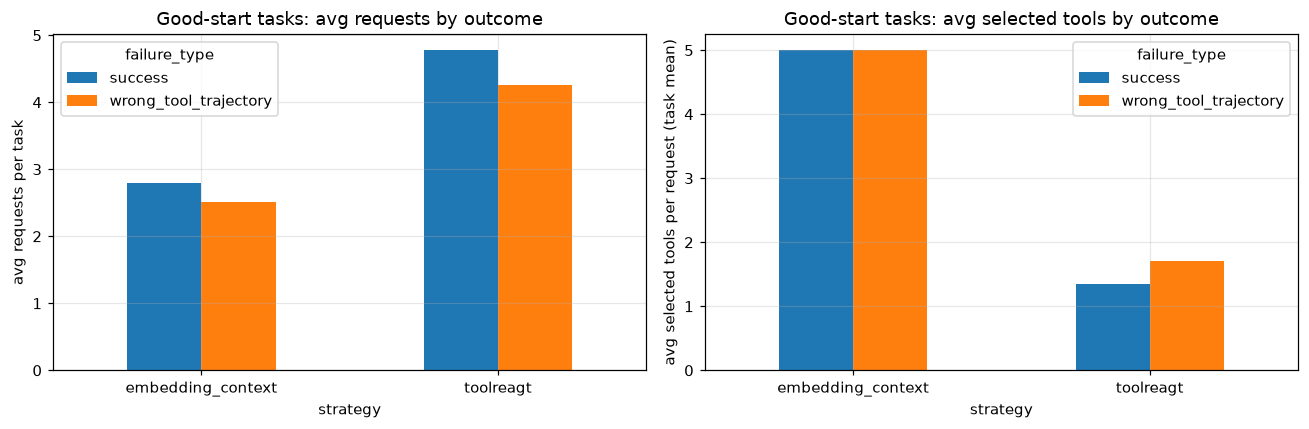

=== Cross-strategy summary ===


,strategy,tasks,avg_requests_per_task,median_requests_per_task,avg_selected_tools,median_selected_tools
0,embedding_context,1020,1.895098,2.0,5.000000,5.0
1,toolreagt,1020,3.390196,3.0,1.532797,1.0



=== Correlation (fewer selected tools vs more requests) ===


,strategy,n_tasks,"pearson(avg_selected, n_requests)","spearman(avg_selected, n_requests)"
0,embedding_context,1020,NaN,NaN
1,toolreagt,1020,0.058547,0.206476



=== Good-start tasks: success vs wrong trajectory ===


,strategy,failure_type,n_tasks,avg_requests_per_task,avg_selected_tools
0,embedding_context,success,154,2.792208,5.000000
1,embedding_context,wrong_tool_trajectory,240,2.504167,5.000000
2,toolreagt,success,148,4.777027,1.350861
3,toolreagt,wrong_tool_trajectory,333,4.255255,1.708213


In [40]:
# Test hypothesis: fewer selected tools -> more uncertainty -> more requests / wrong trajectories
import numpy as np

def _tool_count_from_row(row):
    for c in ["selected_tool_names", "selected_tools", "selected", "selected_tool_list"]:
        if c in row and isinstance(row[c], (list, tuple, set)):
            return len(row[c])
    return np.nan

rq = req_join_df.copy()
rq["n_selected_tools"] = rq.apply(_tool_count_from_row, axis=1)

# Task-level aggregation (same unit used in previous sections)
task_level = (
    rq.groupby(["strategy", "task_id", "task_idx"], as_index=False)
    .agg(
        n_requests=("request_id", "nunique"),
        avg_n_selected_tools=("n_selected_tools", "mean"),
        med_n_selected_tools=("n_selected_tools", "median"),
    )
)

# 1) Cross-strategy comparison of selected tool count and request multiplicity
summary_hyp = (
    task_level.groupby("strategy", as_index=False)
    .agg(
        tasks=("task_id", "count"),
        avg_requests_per_task=("n_requests", "mean"),
        median_requests_per_task=("n_requests", "median"),
        avg_selected_tools=("avg_n_selected_tools", "mean"),
        median_selected_tools=("med_n_selected_tools", "median"),
    )
)

# 2) Within-strategy correlation: fewer selected tools vs. more requests?
corr_rows = []
for s, sub in task_level.groupby("strategy"):
    sub2 = sub[["n_requests", "avg_n_selected_tools"]].dropna()
    if len(sub2) >= 3 and sub2["avg_n_selected_tools"].nunique() > 1 and sub2["n_requests"].nunique() > 1:
        pearson = sub2["avg_n_selected_tools"].corr(sub2["n_requests"], method="pearson")
        spearman = sub2["avg_n_selected_tools"].corr(sub2["n_requests"], method="spearman")
    else:
        pearson = np.nan
        spearman = np.nan
    corr_rows.append({
        "strategy": s,
        "n_tasks": len(sub2),
        "pearson(avg_selected, n_requests)": pearson,
        "spearman(avg_selected, n_requests)": spearman,
    })
corr_hyp = pd.DataFrame(corr_rows)

# 3) Among good-start tasks: compare success vs wrong trajectory
fb = failure_break_df[["strategy", "task_id", "task_idx", "failure_type"]].copy()
fb2 = fb[fb["failure_type"].isin(["success", "wrong_tool_trajectory"])].copy()
merged_hyp = task_level.merge(fb2, on=["strategy", "task_id", "task_idx"], how="inner")

traj_cmp = (
    merged_hyp.groupby(["strategy", "failure_type"], as_index=False)
    .agg(
        n_tasks=("task_id", "count"),
        avg_requests_per_task=("n_requests", "mean"),
        avg_selected_tools=("avg_n_selected_tools", "mean"),
    )
)

# 4) Visual sanity check (matplotlib only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not traj_cmp.empty:
    p1 = traj_cmp.pivot(index="strategy", columns="failure_type", values="avg_requests_per_task")
    p2 = traj_cmp.pivot(index="strategy", columns="failure_type", values="avg_selected_tools")

    p1.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Good-start tasks: avg requests by outcome")
    axes[0].set_ylabel("avg requests per task")
    axes[0].tick_params(axis="x", rotation=0)

    p2.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Good-start tasks: avg selected tools by outcome")
    axes[1].set_ylabel("avg selected tools per request (task mean)")
    axes[1].tick_params(axis="x", rotation=0)
else:
    axes[0].text(0.5, 0.5, "No data", ha="center", va="center")
    axes[1].text(0.5, 0.5, "No data", ha="center", va="center")

plt.tight_layout()
plt.show()

print("=== Cross-strategy summary ===")
display(summary_hyp.sort_values("strategy"))
print("\n=== Correlation (fewer selected tools vs more requests) ===")
display(corr_hyp.sort_values("strategy"))
print("\n=== Good-start tasks: success vs wrong trajectory ===")
display(traj_cmp.sort_values(["strategy", "failure_type"]))

## 14. Statistical task-accuracy comparison

For each executing model, report accuracy and 95% Wilson confidence intervals for the six standard strategies. Each alternative is compared with `in_context` using an exact two-sided McNemar test on paired tasks. Bonferroni correction is applied over the five standard baseline comparisons. ToolReAGT is reported as an additional 120B comparison.

In [41]:
from math import comb, sqrt

BASELINE_STRATEGY = "in_context"


def wilson_ci(correct: int, total: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if total == 0:
        return float("nan"), float("nan")
    p = correct / total
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    half_width = z / denominator * sqrt(p * (1 - p) / total + z**2 / (4 * total**2))
    return max(0.0, center - half_width), min(1.0, center + half_width)


def exact_mcnemar_two_sided(n10: int, n01: int) -> float:
    discordant = n10 + n01
    if discordant == 0:
        return 1.0
    lower_tail = sum(comb(discordant, i) for i in range(min(n10, n01) + 1)) / 2**discordant
    return min(1.0, 2 * lower_tail)


def correctness_map(model: str, strategy: str) -> dict[tuple[str, int], bool]:
    if strategy == "toolreagt":
        return {key: bool(value.get("correct", False)) for key, value in toolreagt_tasks.items()}
    return {key: bool(value.get("correct", False)) for key, value in all_data[model][strategy]["tasks"].items()}


def paired_comparison(model: str, baseline: str, alternative: str) -> dict:
    baseline_map = correctness_map(model, baseline)
    alternative_map = correctness_map(model, alternative)
    keys = sorted(set(baseline_map) & set(alternative_map))
    baseline_values = [baseline_map[key] for key in keys]
    alternative_values = [alternative_map[key] for key in keys]
    n = len(keys)
    baseline_correct = sum(baseline_values)
    alternative_correct = sum(alternative_values)
    n10 = sum(base and not alt for base, alt in zip(baseline_values, alternative_values))
    n01 = sum((not base) and alt for base, alt in zip(baseline_values, alternative_values))
    baseline_ci = wilson_ci(baseline_correct, n)
    alternative_ci = wilson_ci(alternative_correct, n)
    p_value = exact_mcnemar_two_sided(n10, n01)
    return {
        "model": model,
        "baseline": STRATEGY_LABELS.get(baseline, baseline),
        "strategy": "ToolReAGT" if alternative == "toolreagt" else STRATEGY_LABELS[alternative],
        "n_tasks": n,
        "baseline_accuracy_pct": baseline_correct / n * 100,
        "strategy_accuracy_pct": alternative_correct / n * 100,
        "strategy_wilson_95_ci_pct": f"[{alternative_ci[0] * 100:.2f}, {alternative_ci[1] * 100:.2f}]",
        "accuracy_difference_pp": (alternative_correct - baseline_correct) / n * 100,
        "n10_baseline_yes_strategy_no": n10,
        "n01_baseline_no_strategy_yes": n01,
        "p_raw": p_value,
    }


stat_rows = []
for model in MODELS:
    baseline_map = correctness_map(model, BASELINE_STRATEGY)
    for strategy in STRATEGIES:
        current_map = correctness_map(model, strategy)
        keys = sorted(set(baseline_map) & set(current_map))
        correct = sum(current_map[key] for key in keys)
        ci_low, ci_high = wilson_ci(correct, len(keys))
        row = paired_comparison(model, BASELINE_STRATEGY, strategy)
        row.update({
            "accuracy_pct": correct / len(keys) * 100,
            "wilson_95_ci_pct": f"[{ci_low * 100:.2f}, {ci_high * 100:.2f}]",
            "comparison_family": "six standard strategies",
        })
        stat_rows.append(row)

# Preserve the requested five-comparison Bonferroni family.
standard_alternatives = [strategy for strategy in STRATEGIES if strategy != BASELINE_STRATEGY]
for row in stat_rows:
    if row["strategy"] == STRATEGY_LABELS[BASELINE_STRATEGY]:
        row["p_bonferroni"] = float("nan")
        row["significant_alpha_0_05"] = "baseline"
    else:
        row["p_bonferroni"] = min(1.0, row["p_raw"] * len(standard_alternatives))
        row["significant_alpha_0_05"] = "yes" if row["p_bonferroni"] < 0.05 else "no"

# Additional ToolReAGT comparison for 120B; not part of the five-strategy family.
toolreagt_row = paired_comparison("120B", BASELINE_STRATEGY, "toolreagt")
toolreagt_row.update({
    "accuracy_pct": toolreagt_row["strategy_accuracy_pct"],
    "wilson_95_ci_pct": toolreagt_row["strategy_wilson_95_ci_pct"],
    "p_bonferroni": float("nan"),
    "significant_alpha_0_05": "yes" if toolreagt_row["p_raw"] < 0.05 else "no",
    "comparison_family": "additional ToolReAGT comparison",
})
stat_rows.append(toolreagt_row)

stat_df = pd.DataFrame(stat_rows)
display(stat_df[
    [
        "model",
        "comparison_family",
        "baseline",
        "strategy",
        "n_tasks",
        "accuracy_pct",
        "wilson_95_ci_pct",
        "accuracy_difference_pp",
        "n10_baseline_yes_strategy_no",
        "n01_baseline_no_strategy_yes",
        "p_raw",
        "p_bonferroni",
        "significant_alpha_0_05",

    ]].sort_values(["model", "comparison_family", "strategy"]).reset_index(drop=True))

,model,comparison_family,baseline,strategy,n_tasks,accuracy_pct,wilson_95_ci_pct,accuracy_difference_pp,n10_baseline_yes_strategy_no,n01_baseline_no_strategy_yes,p_raw,p_bonferroni,significant_alpha_0_05
0,120B,additional ToolReAGT comparison,In-Context,ToolReAGT,1024,32.910156,"[30.10, 35.85]",-3.320312,82,48,0.003634,NaN,yes
1,120B,six standard strategies,In-Context,Embedding,1024,31.933594,"[29.15, 34.85]",-4.296875,91,47,0.000225,0.001127,yes
2,120B,six standard strategies,In-Context,Embedding+Context,1024,35.839844,"[32.96, 38.82]",-0.390625,66,62,0.791007,1.000000,no
3,120B,six standard strategies,In-Context,Hierarchical,1024,36.425781,"[33.53, 39.42]",0.195312,57,59,0.926078,1.000000,no
4,120B,six standard strategies,In-Context,In-Context,1024,36.230469,"[33.34, 39.22]",0.000000,0,0,1.000000,NaN,baseline
5,120B,six standard strategies,In-Context,Reranker,1024,30.664062,"[27.92, 33.56]",-5.566406,97,40,0.000001,0.000006,yes
6,120B,six standard strategies,In-Context,Reranker+Context,1024,35.156250,"[32.29, 38.13]",-1.074219,61,50,0.342581,1.000000,no
7,Laguna,six standard strategies,In-Context,Embedding,1024,34.472656,"[31.62, 37.44]",-5.664062,106,48,0.000003,0.000017,yes
8,Laguna,six standard strategies,In-Context,Embedding+Context,1024,38.476562,"[35.54, 41.49]",-1.660156,79,62,0.177630,0.888149,no
9,Laguna,six standard strategies,In-Context,Hierarchical,1024,41.015625,"[38.04, 44.06]",0.878906,47,56,0.430689,1.000000,no


## 15. Improvement Strategies: ToolReAGT on Laguna

This section mirrors the dedicated ToolReAGT analysis above for the Laguna executing model: official metrics, strategy comparison, and retrieval quality.

,Model,Strategy,Task Accuracy,Session Accuracy,Tasks Correct,Sessions Correct,Tasks,Sessions
0,Laguna,ToolReAGT,0.397461,0.035156,407,9,1024,256


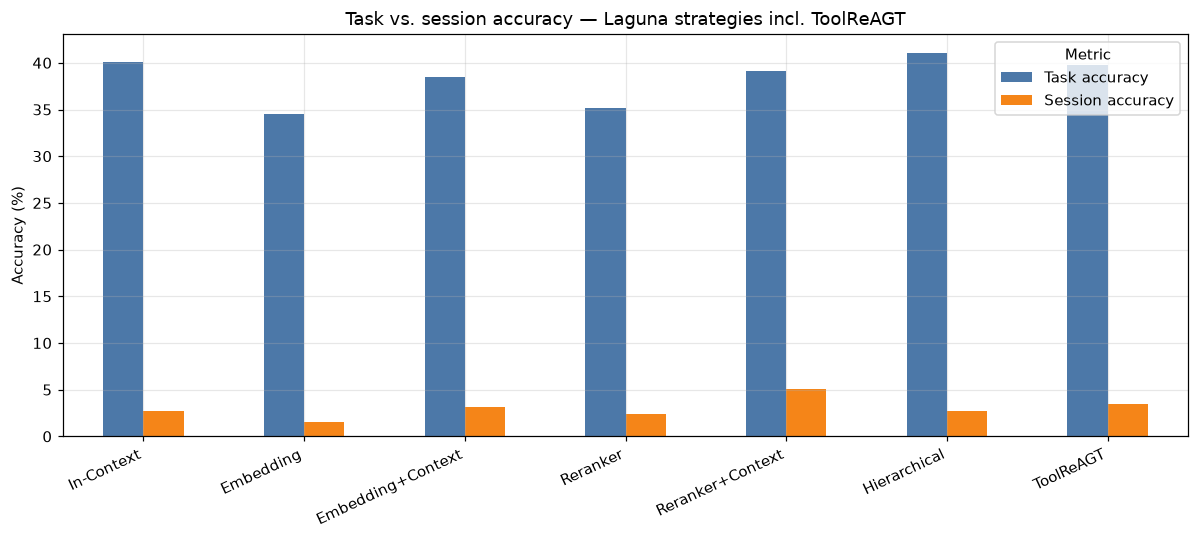

In [42]:
laguna_toolreagt_metric_path = ROOT / "score" / "laguna_toolreagt" / "langgraph" / "Wild-Tool-Bench_metric.json"
laguna_toolreagt_score_path = ROOT / "score" / "laguna_toolreagt" / "langgraph" / "Wild-Tool-Bench_score.jsonl"

with open(laguna_toolreagt_metric_path, encoding="utf-8") as file:
    laguna_toolreagt_metric = json.load(file)
laguna_toolreagt_score_rows = read_jsonl(laguna_toolreagt_score_path)

laguna_toolreagt_summary = pd.DataFrame([{
    "Model": "Laguna",
    "Strategy": "ToolReAGT",
    "Task Accuracy": laguna_toolreagt_metric["total_info"]["task"]["accuracy"],
    "Session Accuracy": laguna_toolreagt_metric["total_info"]["session"]["accuracy"],
    "Tasks Correct": laguna_toolreagt_metric["total_info"]["task"]["correct_count"],
    "Sessions Correct": laguna_toolreagt_metric["total_info"]["session"]["correct_count"],
    "Tasks": laguna_toolreagt_metric["total_info"]["task"]["total_count"],
    "Sessions": laguna_toolreagt_metric["total_info"]["session"]["total_count"],
}])

display(laguna_toolreagt_summary)

# Task vs. session accuracy for ToolReAGT alongside every other Laguna strategy.
compare_strategies_laguna = STRATEGIES + ["toolreagt"]
compare_labels_laguna = {**STRATEGY_LABELS, "toolreagt": "ToolReAGT"}
laguna_accuracy_series = {}
for strategy in STRATEGIES:
    metric = all_data["Laguna"][strategy]["metric"]
    laguna_accuracy_series[strategy] = [
        metric["total_info"]["task"]["accuracy"] * 100,
        metric["total_info"]["session"]["accuracy"] * 100,
    ]
laguna_accuracy_series["toolreagt"] = [
    laguna_toolreagt_metric["total_info"]["task"]["accuracy"] * 100,
    laguna_toolreagt_metric["total_info"]["session"]["accuracy"] * 100,
]

ax = pd.DataFrame(laguna_accuracy_series, index=["Task accuracy", "Session accuracy"]).T.plot(
    kind="bar", figsize=(11, 5), color=["#4c78a8", "#f58518"]
)
ax.set_xticklabels([compare_labels_laguna[s] for s in compare_strategies_laguna], rotation=25, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Task vs. session accuracy — Laguna strategies incl. ToolReAGT")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

,Model,Strategy,Tasks,Gold-tool coverage,Precision@1
0,Laguna,Embedding,768,0.604970,0.520833
1,Laguna,Embedding+Context,768,0.600022,0.471354
2,Laguna,Reranker,768,0.697569,0.657552
3,Laguna,Reranker+Context,768,0.659852,0.554688
4,Laguna,Hierarchical,768,0.773329,0.792969
5,Laguna,ToolReAGT,768,0.718099,0.755208


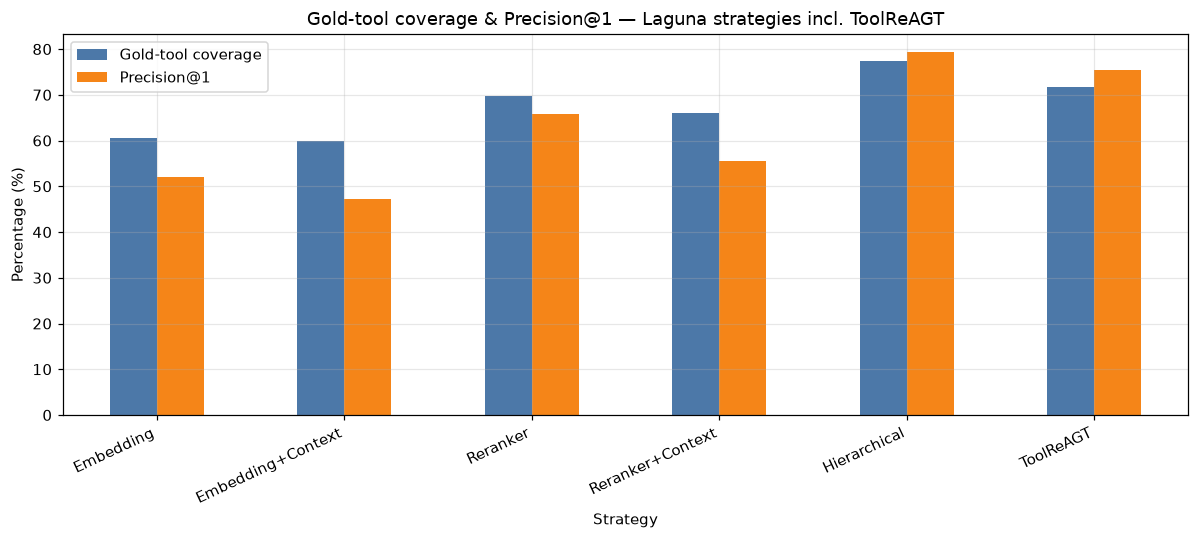

In [43]:
def laguna_toolreagt_retrieval_metrics(strategy: str) -> dict:
    selected_by_task = load_strategy_selection("Laguna", strategy)
    ranked_by_task = load_strategy_selection_ranked("Laguna", strategy)
    rows = []
    for key, gold_entry in gold_index.items():
        gold_tools = set(gold_entry["gold_tools_unique"])
        if not gold_tools:
            continue
        selected_tools = selected_by_task.get(key, set())
        ranked_tools = ranked_by_task.get(key, [])
        top1 = ranked_tools[0] if ranked_tools else None
        rows.append({
            "coverage": len(gold_tools & selected_tools) / len(gold_tools),
            "top1_hit": top1 in gold_tools if top1 else False,
        })
    retrieval_df = pd.DataFrame(rows)
    return {
        "tasks": len(retrieval_df),
        "coverage": retrieval_df["coverage"].mean(),
        "precision_at_1": retrieval_df["top1_hit"].mean(),
    }

laguna_selection_strategies = [
    "embedding",
    "embedding_context",
    "reranker",
    "reranker_context",
    "hierarchical",
    "toolreagt",
]
laguna_retrieval_summary = pd.DataFrame([
    {
        "Model": "Laguna",
        "Strategy": compare_labels_laguna[strategy],
        "Tasks": metrics["tasks"],
        "Gold-tool coverage": metrics["coverage"],
        "Precision@1": metrics["precision_at_1"],
    }
    for strategy in laguna_selection_strategies
    for metrics in [laguna_toolreagt_retrieval_metrics(strategy)]
])
display(laguna_retrieval_summary)

ax = laguna_retrieval_summary.set_index("Strategy")[["Gold-tool coverage", "Precision@1"]].mul(100).plot(
    kind="bar", figsize=(11, 5), color=["#4c78a8", "#f58518"]
)
ax.set_ylabel("Percentage (%)")
ax.set_title("Gold-tool coverage & Precision@1 — Laguna strategies incl. ToolReAGT")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 16. Oracle tool-selection runs: execution variability

Three repeated runs (`oracle_run1/2/3`) were executed per model with the **oracle tool selector**, which always
hands the executor exactly the gold tools for the task. Since tool selection is fixed, any remaining variation
in `correct` across the three runs reflects **stochastic execution behavior** of the executing LLM itself
(sampling, formatting, argument-matching noise, etc.), not tool-selection quality.

This section:
1. Loads the 3 oracle runs per model at task level (1024 tasks / 256 sessions, aligned by `(session_id, task_idx)`).
2. Reports per-run oracle accuracy.
3. Quantifies run-to-run variability (mean, SD, min/max, 95% CI of the mean across the 3 runs).
4. Reports per-task oracle stability (how many of the 3 runs were correct for each task).
5. Reports each strategy's descriptive **gap to oracle** (strategy accuracy − mean oracle accuracy), *not* a
   significance test against the oracle SD.
6. Runs exploratory paired McNemar tests, strategy vs. each individual oracle run.

**Data caveat:** the three `laguna_oracle_run*` score files are byte-for-byte identical (every task has the same
label in all three runs), i.e. Laguna shows zero measured run-to-run variability here. This is called out
explicitly below rather than silently treated as "true" zero-variance evidence — it may reflect a caching/rerun
artifact in the pipeline rather than genuinely deterministic execution.


In [44]:
ORACLE_RUNS = ["oracle_run1", "oracle_run2", "oracle_run3"]
ORACLE_SCORE_DIRS = {
    "120B": {run: f"120B_{run}" for run in ORACLE_RUNS},
    "Laguna": {run: f"laguna_{run}" for run in ORACLE_RUNS},
}


def load_oracle_run_tasks(model: str, run: str) -> dict[tuple[str, int], dict]:
    """Per-task correctness for one oracle run, keyed like the strategy task dicts above."""
    score_rows = read_jsonl(SCORE_ROOT / ORACLE_SCORE_DIRS[model][run] / "langgraph/Wild-Tool-Bench_score.jsonl")
    tasks = {}
    for rec in score_rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            tasks[(eid, i)] = {"correct": item.get("label") == "correct"}
    return tasks


oracle_data = {}
for m in MODELS:
    oracle_data[m] = {}
    for run in ORACLE_RUNS:
        tasks = load_oracle_run_tasks(m, run)
        oracle_data[m][run] = {
            "tasks": tasks,
            "metric": json.load(open(SCORE_ROOT / ORACLE_SCORE_DIRS[m][run] / "langgraph/Wild-Tool-Bench_metric.json")),
        }
        n_tasks = len(tasks)
        n_correct = sum(t["correct"] for t in tasks.values())
        print(f"{m:8s} {run:12s} tasks={n_tasks:4d}  correct={n_correct:4d}  acc={n_correct / n_tasks:.4f}")

# Task IDs aligned across the 3 runs (and with the gold index) for every model.
oracle_common_keys = {}
for m in MODELS:
    keys = set(gold_index.keys())
    for run in ORACLE_RUNS:
        keys &= set(oracle_data[m][run]["tasks"].keys())
    oracle_common_keys[m] = sorted(keys)
    print(f"{m:8s} aligned task keys across all 3 oracle runs: {len(oracle_common_keys[m])}")


120B     oracle_run1  tasks=1024  correct= 398  acc=0.3887
120B     oracle_run2  tasks=1024  correct= 390  acc=0.3809
120B     oracle_run3  tasks=1024  correct= 392  acc=0.3828
Laguna   oracle_run1  tasks=1024  correct= 431  acc=0.4209
Laguna   oracle_run2  tasks=1024  correct= 431  acc=0.4209
Laguna   oracle_run3  tasks=1024  correct= 431  acc=0.4209
120B     aligned task keys across all 3 oracle runs: 1024
Laguna   aligned task keys across all 3 oracle runs: 1024


,model,run,n_tasks,n_correct,accuracy
0,120B,oracle_run1,1024,398,0.388672
1,120B,oracle_run2,1024,390,0.380859
2,120B,oracle_run3,1024,392,0.382812
3,Laguna,oracle_run1,1024,431,0.420898
4,Laguna,oracle_run2,1024,431,0.420898
5,Laguna,oracle_run3,1024,431,0.420898


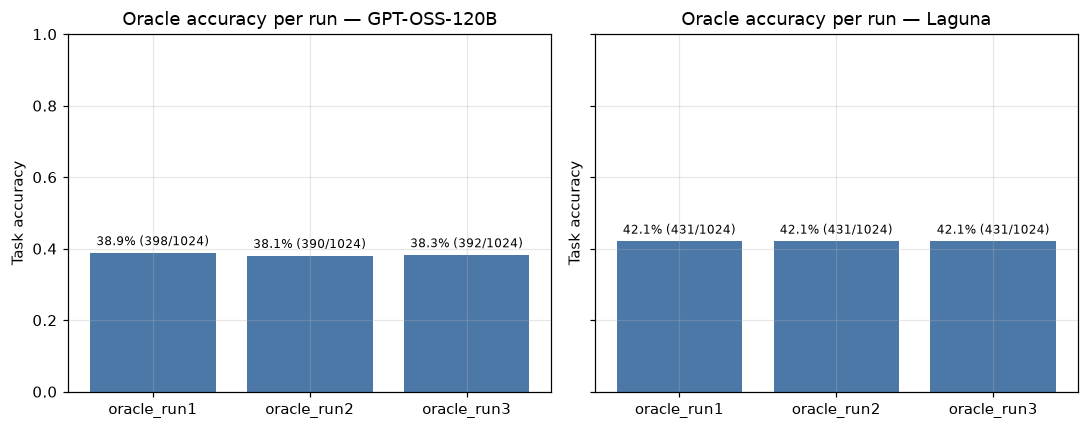

In [45]:
# Per-run oracle accuracy: overall correct rate and correct-count / n_tasks.
oracle_run_rows = []
for m in MODELS:
    keys = oracle_common_keys[m]
    n = len(keys)
    for run in ORACLE_RUNS:
        tasks = oracle_data[m][run]["tasks"]
        n_correct = sum(tasks[key]["correct"] for key in keys)
        oracle_run_rows.append({
            "model": m,
            "run": run,
            "n_tasks": n,
            "n_correct": n_correct,
            "accuracy": n_correct / n,
        })
oracle_run_df = pd.DataFrame(oracle_run_rows)
display(oracle_run_df)

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 4), sharey=True)
for ax, m in zip(axes, MODELS):
    sub = oracle_run_df[oracle_run_df["model"] == m]
    bars = ax.bar(sub["run"], sub["accuracy"], color="#4c78a8")
    ax.bar_label(bars, labels=[f"{v:.1%} ({c}/{n})" for v, c, n in zip(sub["accuracy"], sub["n_correct"], sub["n_tasks"])], padding=3, fontsize=8)
    ax.set_title(f"Oracle accuracy per run — {MODEL_LABELS[m]}")
    ax.set_ylabel("Task accuracy")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Run-to-run oracle variability (uncertainty across the 3 repeated oracle runs, NOT strategy variance):


,model,n_runs,mean_oracle_accuracy,sd_across_runs,min_accuracy,max_accuracy,ci95_across_3_runs_low,ci95_across_3_runs_high
0,120B,3,0.384115,0.004066,0.380859,0.388672,0.374015,0.394214
1,Laguna,3,0.420898,0.000000,0.420898,0.420898,0.420898,0.420898


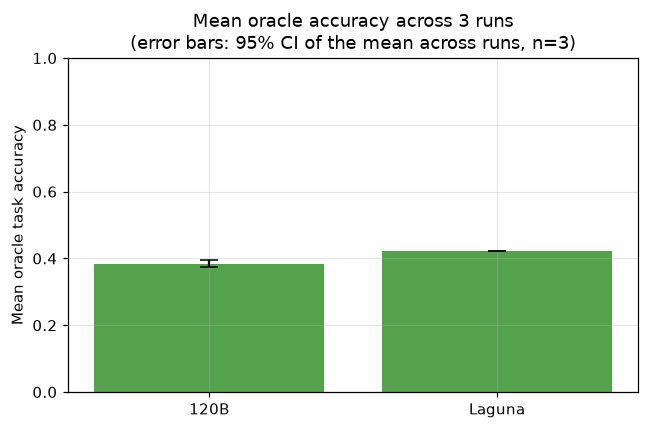

In [46]:
# Run-to-run variability across the 3 oracle runs (uncertainty ACROSS RUNS, not within-run sampling noise).
# n=3 -> use Student's t (df=2, t_0.975=4.302652729911275) for the 95% CI of the mean.
T_CRIT_DF2 = 4.302652729911275

oracle_variability_rows = []
for m in MODELS:
    accs = oracle_run_df.loc[oracle_run_df["model"] == m, "accuracy"].tolist()
    n = len(accs)
    mean_acc = sum(accs) / n
    variance = sum((a - mean_acc) ** 2 for a in accs) / (n - 1)  # sample SD, n=3
    sd = sqrt(variance)
    sem = sd / sqrt(n)
    ci_low, ci_high = mean_acc - T_CRIT_DF2 * sem, mean_acc + T_CRIT_DF2 * sem
    oracle_variability_rows.append({
        "model": m,
        "n_runs": n,
        "mean_oracle_accuracy": mean_acc,
        "sd_across_runs": sd,
        "min_accuracy": min(accs),
        "max_accuracy": max(accs),
        "ci95_across_3_runs_low": ci_low,
        "ci95_across_3_runs_high": ci_high,
    })

oracle_variability_df = pd.DataFrame(oracle_variability_rows)
print("Run-to-run oracle variability (uncertainty across the 3 repeated oracle runs, NOT strategy variance):")
display(oracle_variability_df)

ORACLE_MEAN_ACCURACY = dict(zip(oracle_variability_df["model"], oracle_variability_df["mean_oracle_accuracy"]))

fig, ax = plt.subplots(figsize=(6, 4))
means = [ORACLE_MEAN_ACCURACY[m] for m in MODELS]
errs_low = [ORACLE_MEAN_ACCURACY[m] - oracle_variability_df.loc[oracle_variability_df["model"] == m, "ci95_across_3_runs_low"].iloc[0] for m in MODELS]
errs_high = [oracle_variability_df.loc[oracle_variability_df["model"] == m, "ci95_across_3_runs_high"].iloc[0] - ORACLE_MEAN_ACCURACY[m] for m in MODELS]
ax.bar(MODELS, means, yerr=[errs_low, errs_high], capsize=6, color="#54a24b")
ax.set_ylabel("Mean oracle task accuracy")
ax.set_title("Mean oracle accuracy across 3 runs\n(error bars: 95% CI of the mean across runs, n=3)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Per-task oracle stability (n of 3 runs correct):


,model,n_correct_runs,n_tasks,share_of_tasks
3,120B,3,363,0.354492
2,120B,2,30,0.029297
1,120B,1,31,0.030273
0,120B,0,600,0.585938
5,Laguna,3,431,0.420898
4,Laguna,0,593,0.579102


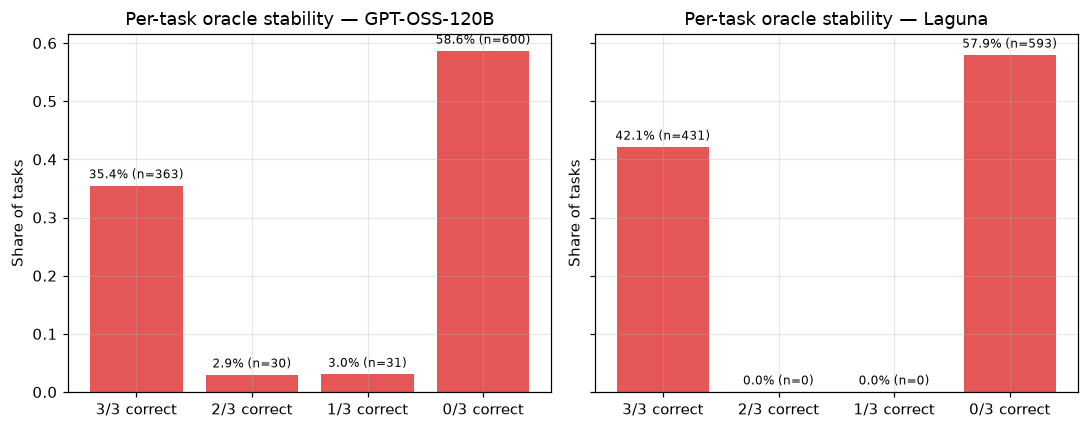

In [47]:
# Per-task oracle stability: how many of the 3 oracle runs were correct, per task.
# Under a fixed (oracle) tool selection, tasks that flip between runs indicate execution-side stochasticity.
oracle_stability_rows = []
for m in MODELS:
    keys = oracle_common_keys[m]
    for key in keys:
        n_correct_runs = sum(oracle_data[m][run]["tasks"][key]["correct"] for run in ORACLE_RUNS)
        oracle_stability_rows.append({"model": m, "task_id": key[0], "task_idx": key[1], "n_correct_runs": n_correct_runs})

oracle_stability_df = pd.DataFrame(oracle_stability_rows)

stability_summary = (
    oracle_stability_df.groupby(["model", "n_correct_runs"]).size().rename("n_tasks").reset_index()
)
stability_summary["share_of_tasks"] = stability_summary["n_tasks"] / stability_summary.groupby("model")["n_tasks"].transform("sum")
stability_summary = stability_summary.sort_values(["model", "n_correct_runs"], ascending=[True, False])
print("Per-task oracle stability (n of 3 runs correct):")
display(stability_summary)

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 4), sharey=True)
for ax, m in zip(axes, MODELS):
    sub = stability_summary[stability_summary["model"] == m].set_index("n_correct_runs").reindex([3, 2, 1, 0]).fillna(0)
    labels = [f"{k}/3 correct" for k in sub.index]
    bars = ax.bar(labels, sub["share_of_tasks"], color="#e45756")
    ax.bar_label(bars, labels=[f"{v:.1%} (n={int(n)})" for v, n in zip(sub["share_of_tasks"], sub["n_tasks"])], padding=3, fontsize=8)
    ax.set_title(f"Per-task oracle stability — {MODEL_LABELS[m]}")
    ax.set_ylabel("Share of tasks")
plt.tight_layout()
plt.show()


,model,strategy,strategy_accuracy,mean_oracle_accuracy,gap_to_oracle_pp
0,120B,In-Context,0.362305,0.384115,-2.180990
1,120B,Embedding,0.319336,0.384115,-6.477865
2,120B,Embedding+Context,0.358398,0.384115,-2.571615
3,120B,Reranker,0.306641,0.384115,-7.747396
4,120B,Reranker+Context,0.351562,0.384115,-3.255208
5,120B,Hierarchical,0.364258,0.384115,-1.985677
6,Laguna,In-Context,0.401367,0.420898,-1.953125
7,Laguna,Embedding,0.344727,0.420898,-7.617188
8,Laguna,Embedding+Context,0.384766,0.420898,-3.613281
9,Laguna,Reranker,0.351562,0.420898,-6.933594


/tmp/ipykernel_3650098/2712258018.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(sub["strategy"], rotation=25, ha="right")
/tmp/ipykernel_3650098/2712258018.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(sub["strategy"], rotation=25, ha="right")


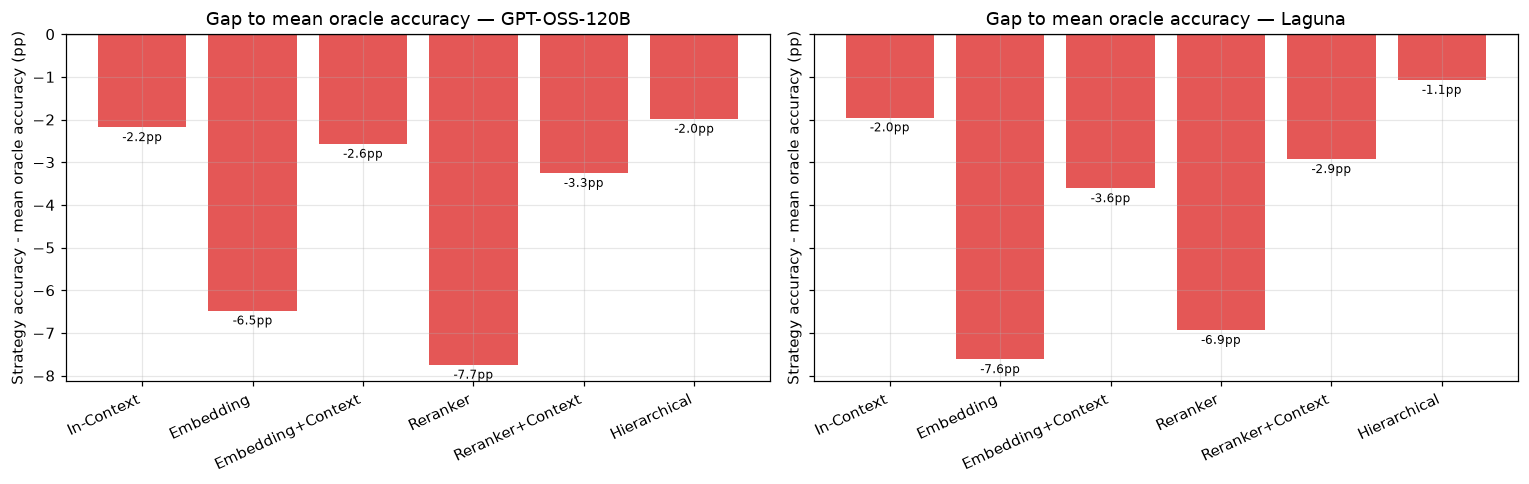

In [48]:
# Gap to oracle per strategy: strategy accuracy - mean oracle accuracy (same model).
# Descriptive only: do NOT use the oracle SD as the variance of the six strategies (see markdown above).
gap_rows = []
for m in MODELS:
    oracle_mean = ORACLE_MEAN_ACCURACY[m]
    for s in STRATEGIES:
        strategy_acc = all_data[m][s]["metric"]["total_info"]["task"]["accuracy"]
        gap_rows.append({
            "model": m,
            "strategy": STRATEGY_LABELS[s],
            "strategy_accuracy": strategy_acc,
            "mean_oracle_accuracy": oracle_mean,
            "gap_to_oracle_pp": (strategy_acc - oracle_mean) * 100,
        })
gap_to_oracle_df = pd.DataFrame(gap_rows)
display(gap_to_oracle_df)

fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 4.5), sharey=True)
for ax, m in zip(axes, MODELS):
    sub = gap_to_oracle_df[gap_to_oracle_df["model"] == m]
    colors = ["#54a24b" if v >= 0 else "#e45756" for v in sub["gap_to_oracle_pp"]]
    bars = ax.bar(sub["strategy"], sub["gap_to_oracle_pp"], color=colors)
    ax.bar_label(bars, labels=[f"{v:+.1f}pp" for v in sub["gap_to_oracle_pp"]], padding=3, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Gap to mean oracle accuracy — {MODEL_LABELS[m]}")
    ax.set_ylabel("Strategy accuracy - mean oracle accuracy (pp)")
    ax.set_xticklabels(sub["strategy"], rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [49]:
# Exploratory paired McNemar tests: each strategy vs. each individual oracle run, on aligned tasks.
# These are descriptive/exploratory comparisons, additional to (not replacing) the section-14 strategy-vs-strategy tests.
oracle_mcnemar_rows = []
for m in MODELS:
    strategy_maps = {s: correctness_map(m, s) for s in STRATEGIES}
    for run in ORACLE_RUNS:
        oracle_map = {key: value["correct"] for key, value in oracle_data[m][run]["tasks"].items()}
        for s in STRATEGIES:
            strategy_map = strategy_maps[s]
            keys = sorted(set(strategy_map) & set(oracle_map))
            n = len(keys)
            strategy_values = [strategy_map[k] for k in keys]
            oracle_values = [oracle_map[k] for k in keys]
            n10 = sum(sv and not ov for sv, ov in zip(strategy_values, oracle_values))
            n01 = sum((not sv) and ov for sv, ov in zip(strategy_values, oracle_values))
            p_value = exact_mcnemar_two_sided(n10, n01)
            oracle_mcnemar_rows.append({
                "model": m,
                "strategy": STRATEGY_LABELS[s],
                "oracle_run": run,
                "n_tasks": n,
                "strategy_accuracy_pct": sum(strategy_values) / n * 100,
                "oracle_run_accuracy_pct": sum(oracle_values) / n * 100,
                "n10_strategy_yes_oracle_no": n10,
                "n01_strategy_no_oracle_yes": n01,
                "p_raw": p_value,
                "significant_alpha_0_05": "yes" if p_value < 0.05 else "no",
            })

oracle_mcnemar_df = pd.DataFrame(oracle_mcnemar_rows)
display(oracle_mcnemar_df.sort_values(["model", "strategy", "oracle_run"]).reset_index(drop=True))


,model,strategy,oracle_run,n_tasks,strategy_accuracy_pct,oracle_run_accuracy_pct,n10_strategy_yes_oracle_no,n01_strategy_no_oracle_yes,p_raw,significant_alpha_0_05
0,120B,Embedding,oracle_run1,1024,31.933594,38.867188,26,97,7.967669e-11,yes
1,120B,Embedding,oracle_run2,1024,31.933594,38.085938,35,98,4.292058e-08,yes
2,120B,Embedding,oracle_run3,1024,31.933594,38.281250,35,100,1.940951e-08,yes
3,120B,Embedding+Context,oracle_run1,1024,35.839844,38.867188,35,66,2.653786e-03,yes
4,120B,Embedding+Context,oracle_run2,1024,35.839844,38.085938,43,66,3.461537e-02,yes
5,120B,Embedding+Context,oracle_run3,1024,35.839844,38.281250,44,69,2.353400e-02,yes
6,120B,Hierarchical,oracle_run1,1024,36.425781,38.867188,37,62,1.543236e-02,yes
7,120B,Hierarchical,oracle_run2,1024,36.425781,38.085938,36,53,8.932074e-02,no
8,120B,Hierarchical,oracle_run3,1024,36.425781,38.281250,37,56,6.138590e-02,no
9,120B,In-Context,oracle_run1,1024,36.230469,38.867188,33,60,6.695018e-03,yes
